# Raport z Transformacji Danych i Inżynierii Cech
**Potok danych (Data Pipeline) tworzący zbiór produkcyjny**

W tym notatniku implementujemy decyzje podjęte podczas Eksploracyjnej Analizy Danych (EDA). Dokonujemy czyszczenia, imputacji i transformacji danych. Na koniec tworzymy ustrukturyzowane zbiory: `historical_dataset.csv` oraz `production_dataset.csv`.

## Plik reviews.csv

Pozostawienie średniej opinii każdego listingu z ostatnich 12 miesięcy oraz całej historii

In [191]:
import pandas as pd

# =========================
# Konfiguracja
# =========================

INPUT_FILE = "data/reviews.csv"
OUTPUT_FILE = "data/transformed_reviews.csv"

TODAY = pd.Timestamp("2024-12-21")
DATE_YEAR_AGO = TODAY - pd.Timedelta(days=365)

# =========================
# Wczytanie danych
# =========================

df = pd.read_csv(
    INPUT_FILE,
    dtype={"listing_id": "int64", "numerical_review": "float"},
    low_memory=False,
)

# =========================
# Konwersja dat
# =========================

df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")

# =========================
# Wszystkie listingi
# =========================

all_listing_ids = pd.DataFrame({"listing_id": df["listing_id"].unique()})

# =========================
# Ostatni rok
# =========================

df_yr = df[df["date"] >= DATE_YEAR_AGO]

reviews_yr = (
    df_yr.groupby("listing_id")["numerical_review"]
    .agg(numerical_review_mean_yr="mean", review_cnt_yr="count")
    .reset_index()
)

# =========================
# Cała historia
# =========================

reviews_all = (
    df.groupby("listing_id")["numerical_review"]
    .agg(numerical_review_mean="mean", review_cnt="count")
    .reset_index()
)

# =========================
# Łączenie
# =========================

result = all_listing_ids.merge(reviews_yr, on="listing_id", how="left").merge(
    reviews_all, on="listing_id", how="left"
)

# =========================
# Fill NA
# =========================

result["review_cnt_yr"] = result["review_cnt_yr"].fillna(0)
result["review_cnt"] = result["review_cnt"].fillna(0)

result["numerical_review_mean_yr"] = result["numerical_review_mean_yr"].fillna(0)

result["numerical_review_mean"] = result["numerical_review_mean"].fillna(0)

# =========================
# Jeśli brak opinii w roku
# -> użyj średniej z całej historii
# =========================

mask = result["review_cnt_yr"] == 0

result.loc[mask, "numerical_review_mean_yr"] = result.loc[
    mask, "numerical_review_mean"
]

# =========================
# Typy danych
# =========================

result["review_cnt_yr"] = result["review_cnt_yr"].astype(int)
result["review_cnt"] = result["review_cnt"].astype(int)

# =========================
# Zaokrąglenia
# =========================

result["numerical_review_mean_yr"] = result["numerical_review_mean_yr"].round(2)

result["numerical_review_mean"] = result["numerical_review_mean"].round(2)

# =========================
# Zapis
# =========================

# save only numerical_review_mean_yr and numerical_review_mean columns
result = result[["listing_id", "numerical_review_mean_yr", "numerical_review_mean"]]
result.to_csv(OUTPUT_FILE, index=False)

print(f"Zapisano plik: {OUTPUT_FILE}")

Zapisano plik: data/transformed_reviews.csv


## Plik sessions.csv

Obliczenie:
- wyświetleń oraz rezerwacji z ostatnich 30 dni, roku i całej historii
- średniej, sumy, max i min liczby dni długości rezerwacji z ostatniego roku i całej historii
- średniego czasu od kliknięcia do rozpoczęcia okresu rezerwacji

In [192]:
# =========================
# Konfiguracja
# =========================

INPUT_FILE = "data/sessions.csv"
OUTPUT_FILE = "data/transformed_sessions.csv"

TODAY = pd.Timestamp("2024-12-21")

# =========================
# Nazwy kolumn
# =========================

cols = [
    "event_type",
    "user_id",
    "timestamp",
    "listing_id",
    "booking_date",
    "booking_duration",
    "booking_id",
    "price",
]

# =========================
# Wczytanie danych
# =========================
# dtype=str eliminuje DtypeWarning
# low_memory=False poprawia stabilność parsowania

df = pd.read_csv(INPUT_FILE, names=cols, header=None, dtype=str, low_memory=False)

# =========================
# Konwersje typów
# =========================

# jawne formaty dat eliminują warningi

df["timestamp"] = pd.to_datetime(
    df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

df["booking_date"] = pd.to_datetime(
    df["booking_date"], format="%Y-%m-%d", errors="coerce"
)

df["listing_id"] = pd.to_numeric(df["listing_id"], errors="coerce")

df["booking_duration"] = pd.to_numeric(df["booking_duration"], errors="coerce")

# =========================
# Czyszczenie danych
# =========================

df = df.dropna(subset=["listing_id"])

df["listing_id"] = df["listing_id"].astype("int64")

# =========================
# Okna czasowe
# =========================

date_30 = TODAY - pd.Timedelta(days=30)
date_yr = TODAY - pd.Timedelta(days=365)

# =========================
# VIEW LISTING
# =========================

views = df[df["event_type"] == "view_listing"].copy()

view_cnt = views.groupby("listing_id").size().rename("view_cnt")

view_cnt_30 = (
    views[views["timestamp"] >= date_30]
    .groupby("listing_id")
    .size()
    .rename("view_cnt_30")
)

view_cnt_yr = (
    views[views["timestamp"] >= date_yr]
    .groupby("listing_id")
    .size()
    .rename("view_cnt_yr")
)

# =========================
# BOOK LISTING
# =========================

books = df[df["event_type"] == "book_listing"].copy()

book_cnt = books.groupby("listing_id").size().rename("book_cnt")

book_cnt_30 = (
    books[books["timestamp"] >= date_30]
    .groupby("listing_id")
    .size()
    .rename("book_cnt_30")
)

book_cnt_yr = (
    books[books["timestamp"] >= date_yr]
    .groupby("listing_id")
    .size()
    .rename("book_cnt_yr")
)

# =========================
# booking_duration stats
# =========================

books_yr = books[books["timestamp"] >= date_yr]

booked_days_yr = books_yr.groupby("listing_id")["booking_duration"].agg(
    booked_days_sum_yr="sum",
    booked_days_mean_yr="mean",
    booked_days_min_yr="min",
    booked_days_max_yr="max",
)

booked_days_all = books.groupby("listing_id")["booking_duration"].agg(
    booked_days_sum="sum",
    booked_days_mean="mean",
    booked_days_min="min",
    booked_days_max="max",
)

# =========================
# Średni czas:
# timestamp -> booking_date
# =========================

books["view_to_book_days"] = (
    books["booking_date"] - books["timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

view_to_book_avg = (
    books.groupby("listing_id")["view_to_book_days"]
    .mean()
    .rename("view_to_book_avg")
)

# =========================
# Wszystkie listing_id
# =========================

all_listing_ids = pd.DataFrame({"listing_id": df["listing_id"].unique()})

# =========================
# Łączenie
# =========================

result = (
    all_listing_ids.merge(view_cnt_30, on="listing_id", how="left")
    .merge(view_cnt_yr, on="listing_id", how="left")
    .merge(view_cnt, on="listing_id", how="left")
    .merge(book_cnt_30, on="listing_id", how="left")
    .merge(book_cnt_yr, on="listing_id", how="left")
    .merge(book_cnt, on="listing_id", how="left")
    .merge(booked_days_yr, on="listing_id", how="left")
    .merge(booked_days_all, on="listing_id", how="left")
    .merge(view_to_book_avg, on="listing_id", how="left")
)

# =========================
# ever_booked + specjalne fill dla cech rezerwacji
# =========================

# 1 = listing miał przynajmniej jedną rezerwację
# 0 = nigdy nie miał rezerwacji
result["ever_booked"] = result["book_cnt"].notna().astype(int)

# dla listingów bez rezerwacji ustawiamy -1
special_cols = [
    "booked_days_mean_yr",
    "booked_days_mean",
    "view_to_book_avg",
]

result[special_cols] = result[special_cols].fillna(-1)

# pozostałe braki uzupełniamy zerami
result = result.fillna(0)

# =========================
# Typy int dla liczników
# =========================

int_cols = [
    "view_cnt_30",
    "view_cnt_yr",
    "view_cnt",
    "book_cnt_30",
    "book_cnt_yr",
    "book_cnt",
    "booked_days_sum_yr",
    "booked_days_min_yr",
    "booked_days_max_yr",
    "booked_days_sum",
    "booked_days_min",
    "booked_days_max",
    "ever_booked",
]

for col in int_cols:
    result[col] = result[col].astype(int)

# =========================
# Zaokrąglenia
# =========================

float_cols = ["booked_days_mean_yr", "booked_days_mean", "view_to_book_avg"]

result[float_cols] = result[float_cols].round(2)

# =========================
# Zapis
# =========================

result.to_csv(OUTPUT_FILE, index=False)

print(f"Zapisano plik: {OUTPUT_FILE}")

Zapisano plik: data/transformed_sessions.csv


## Plik listings.csv

In [193]:
df = pd.read_csv("data/listings.csv")

columns_to_keep = [
    "id",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "host_total_listings_count",
    "host_has_profile_pic",
    "host_identity_verified",
    "host_since",
    "room_type",
    "property_type",
    "accommodates",
    "amenities",
    "bathrooms",
    "bedrooms",
    "beds",
    "price",
    "latitude",
    "longitude",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "instant_bookable",
    "calculated_host_listings_count",
    "reviews_per_month"
]

df = df[columns_to_keep]

### Zakodowanie kolumn t/f na 1/0

+imputacja klasą większościową

In [194]:
# kolumny binarne t/f
binary_cols = [
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable'
]

# host_is_superhost ma wartości NA, więc trzeba uzupełnić braki przed kodowaniem
# sprawdzenie liczby t/f w host_is_superhost (bez NA)
counts = df['host_is_superhost'].value_counts(dropna=True)

t_count = counts.get('t', 0)
f_count = counts.get('f', 0)

print("Liczba wartości w 'host_is_superhost' (bez NA):")
print(f"Liczba 't': {t_count}")
print(f"Liczba 'f': {f_count}")
print("uzupełnienie braków w 'host_is_superhost' wartością większościową -", 't' if t_count >= f_count else 'f')

# klasa większościowa
majority_class = counts.idxmax()

# uzupełnienie braków
df['host_is_superhost'] = df['host_is_superhost'].fillna(majority_class)

# kodowanie t -> 1, f -> 0
mapping = {'t': 1, 'f': 0}

for col in binary_cols:
    df[col] = df[col].map(mapping)

Liczba wartości w 'host_is_superhost' (bez NA):
Liczba 't': 337
Liczba 'f': 1100
uzupełnienie braków w 'host_is_superhost' wartością większościową - f


### Usuwanie znaków %, $ itp.

+imputacja braków średnią w kolumnach 'host_response_rate' i 'host_acceptance_rate'

In [195]:
# kolumny procentowe -> float 0-1
rate_cols = ['host_response_rate', 'host_acceptance_rate']

for col in rate_cols:
    df[col] = (
        df[col]
        .str.rstrip('%')
        .astype(float) / 100
    )
    
    # uzupełnienie NA średnią
    print(f"Uzupełnienie braków w '{col}' wartością {df[col].mean():.2f}.")
    df[col] = df[col].fillna(df[col].mean())

# usunięcie $ z price
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

Uzupełnienie braków w 'host_response_rate' wartością 0.92.
Uzupełnienie braków w 'host_acceptance_rate' wartością 0.82.


### Wyłuskanie roku z kolumny host_since

In [196]:
df["host_since"] = pd.to_datetime(
    df["host_since"],
    errors="coerce"
).dt.year

### Sprawdzenie tekstowych kolumn

In [197]:
import ast

print("Unikalne wartości room_type:")
print(df["room_type"].unique())

print("\nLiczba i unikalne wartości property_type:")
unique = df["property_type"].unique()
print(len(unique), unique)

all_amenities = set()

for amenities_str in df["amenities"].dropna():

    try:
        # Zamiana stringa JSON/listy na listę Pythona
        amenities_list = ast.literal_eval(amenities_str)

        if isinstance(amenities_list, list):
            for amenity in amenities_list:
                all_amenities.add(amenity)

    except Exception:
        pass

print("\nLiczba i unikalne amenities:")
print(len(all_amenities))
for amenity in sorted(all_amenities):
    print(amenity)

print(f"\nLiczba unikalnych amenities: {len(all_amenities)}")

Unikalne wartości room_type:
['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']

Liczba i unikalne wartości property_type:
41 ['Entire rental unit' 'Private room in rental unit' 'Private room in home'
 'Entire serviced apartment' 'Entire home' 'Private room in condo'
 'Entire condo' 'Entire bungalow' 'Private room in serviced apartment'
 'Entire townhouse' 'Entire vacation home' 'Entire loft'
 'Entire guest suite' 'Room in hotel' 'Room in boutique hotel' 'Houseboat'
 'Private room in guesthouse' 'Private room in castle'
 'Private room in loft' 'Private room in casa particular'
 'Private room in houseboat' 'Private room in townhouse' 'Tiny home'
 'Entire guesthouse' 'Private room in boat' 'Private room in guest suite'
 'Shared room in hostel' 'Private room in bed and breakfast'
 'Room in serviced apartment' 'Private room' 'Room in aparthotel'
 'Casa particular' 'Shared room in rental unit' 'Private room in hostel'
 'Entire place' 'Camper/RV' 'Entire cabin'
 'Shared room in be

### Porównanie kolumn room_type z property_type

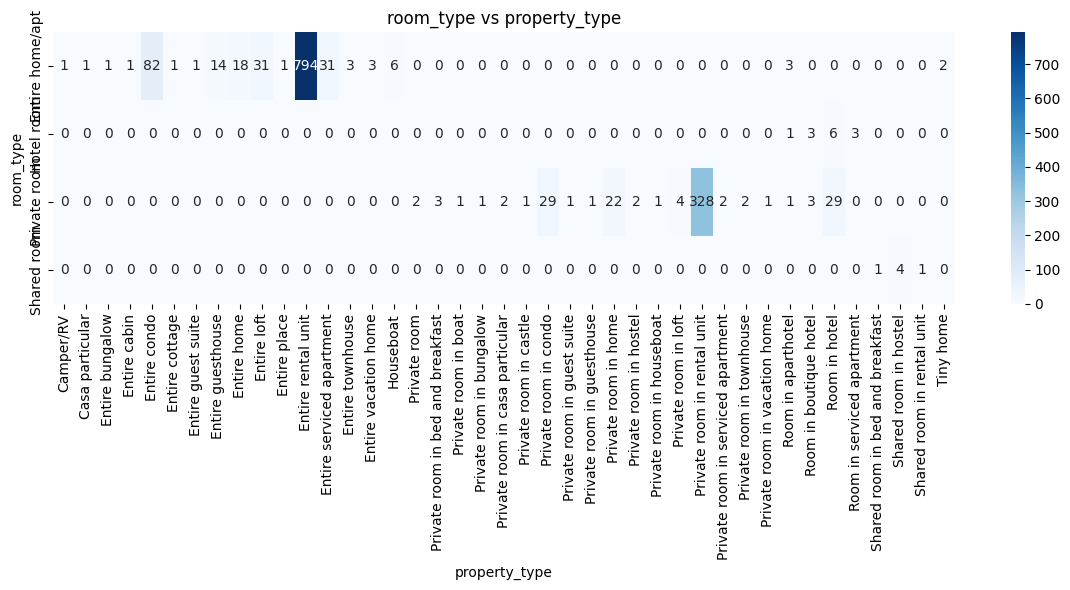

In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# zamiana NA na jawne etykiety
df["room_type"] = df["room_type"].fillna("NA")
df["property_type"] = df["property_type"].fillna("NA")

# tabela liczności
ct = pd.crosstab(
    df["room_type"],
    df["property_type"],
    dropna=False
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("room_type vs property_type")
plt.xlabel("property_type")
plt.ylabel("room_type")

plt.tight_layout()
plt.show()

Zaproponowane kodowanie (room_type):
- Entire home/apt: 0
- Private room: 1
- Other: 2

I odrzucenie kolumny property_type

### Kodowanie porządkowe kolumny room_type

In [199]:
room_type_mapping = {
    "Entire home/apt": 0,
    "Private room": 1,
}

# podmiana room_type w miejscu
df["room_type"] = (
    df["room_type"]
    .map(room_type_mapping)
    .fillna(2)
    .astype(int)
)

df = df.drop(columns=["property_type"])

### Transformacja amenities -> (count, premium_score)

In [200]:
import pandas as pd
import ast

# ============================================
# policz global frequencies
# ============================================

all_amenities = []

for amenities_str in df["amenities"].dropna():

    try:
        amenities_list = ast.literal_eval(amenities_str)
        all_amenities.extend(amenities_list)

    except:
        pass

amenity_freq = pd.Series(all_amenities).value_counts(normalize=True)

# ============================================
# feature engineering
# ============================================

def process_amenities(x):

    try:
        amenities = ast.literal_eval(x)

    except:
        amenities = []

    # 1. liczba amenities
    amenities_count = len(amenities)

    # 2. premium score
    premium_score = 0

    for a in amenities:

        freq = amenity_freq.get(a, 0.001)

        premium_score += 1 / freq

    premium_score = premium_score / amenities_count if amenities_count > 0 else 0

    return pd.Series([
        amenities_count,
        premium_score
        ])

df[
    [
        "amenities_count",
        "amenities_premium_score"
    ]
] = df["amenities"].apply(process_amenities)
df = df.drop(columns=["amenities"])

#### Zapisanie do pliku na koniec

In [201]:
df.to_csv("data/transformed_listings.csv", index=False)

## Pliki calendar.csv i users.csv

Dane z pliku calendar.csv nie zawierają bardzo odmiennych informacji od tych zawartych już w plikach listings, reviews i sessions.  
Dane z pliku users.csv zostaną zignorowane.

## Tworzenie połączonego zbioru danych

In [202]:
# wczytanie danych
listings = pd.read_csv('data/transformed_listings.csv')
sessions = pd.read_csv('data/transformed_sessions.csv')
reviews = pd.read_csv('data/transformed_reviews.csv')

# merge 1:1
df = listings.merge(
    sessions,
    left_on='id',
    right_on='listing_id',
    how='left'
)

df = df.merge(
    reviews,
    left_on='id',
    right_on='listing_id',
    how='left'
)

# opcjonalnie usunięcie duplikujących się kluczy
df = df.drop(columns=['listing_id_x', 'listing_id_y'], errors='ignore')

In [203]:
listings['id'] = listings['id'].astype(int)
sessions['listing_id'] = sessions['listing_id'].astype(int)
reviews['listing_id'] = reviews['listing_id'].astype(int)

# =========================
# SPRAWDZENIE BRAKÓW W MERGU
# =========================

reviews_missing = ~reviews['listing_id'].isin(listings['id'])
sessions_missing = ~sessions['listing_id'].isin(listings['id'])

print(f'Niedopasowane reviews: {reviews_missing.sum() / len(reviews) * 100:.2f}%')
print(f'Niedopasowane sessions: {sessions_missing.sum() / len(sessions) * 100:.2f}%')

Niedopasowane reviews: 0.00%
Niedopasowane sessions: 42.86%


### Odszumianie id

Ponad 40% id z pliku sessions.csv nie pasują idealnie do id z listings.csv, zazwyczaj ostatnimi dwiema/trzema spośród kilkunastu cyfr, podczas gdy do kolejnego id potrzeba zmiany ostatnich ok. 8-10 cyfr. Liczba unikalnych id w listings.csv i sessions.csv jest identyczna. W związku z tym wnioskuję, że nastąpiło zaszumienie wartości id i będę dopasowywał do najbliższej pasującej wartości.

In [204]:
listing_ids = listings['id'].values

# =========================
# ZAJĘTE ID
# =========================

# ID już poprawnie sparowane bezpośrednio
used_ids = set(
    sessions.loc[~sessions_missing, 'listing_id']
)

# =========================
# NAPRAWA sessions
# =========================

def fix_id(x, possible_ids, used_ids):

    for n in range(6):  # 0,1,2,3,4,5
        
        divisor = 10 ** n
        prefix = x // divisor
        
        candidates = possible_ids[possible_ids // divisor == prefix]

        # zostaw tylko wolne ID
        candidates = [c for c in candidates if c not in used_ids]

        if len(candidates) > 0:
            
            candidates = pd.Series(candidates)

            # wybór najbliższego liczbowo
            best_match = candidates.iloc[
                (candidates - x).abs().argmin()
            ]

            # oznacz jako zajęte
            used_ids.add(best_match)

            return best_match

    return x

# naprawa tylko niedopasowanych
sessions.loc[sessions_missing, 'listing_id'] = (
    sessions.loc[sessions_missing, 'listing_id']
    .apply(lambda x: fix_id(x, listing_ids, used_ids))
)

# =========================
# SPRAWDZENIE PO NAPRAWIE
# =========================

sessions_missing_after = ~sessions['listing_id'].isin(listings['id'])

print(f'Niedopasowane sessions po naprawie: {sessions_missing_after.sum() / len(sessions) * 100:.2f}%')

Niedopasowane sessions po naprawie: 0.00%


In [205]:
# =========================
# REBUILD DATASET PO FIXIE
# =========================

df = listings.merge(
    sessions,
    left_on='id',
    right_on='listing_id',
    how='left'
).merge(
    reviews,
    left_on='id',
    right_on='listing_id',
    how='left',
    suffixes=('_sess', '_rev')
)

df = df.drop(columns=['listing_id_sess', 'listing_id_rev'], errors='ignore')

### Sprawdzenie pozostałych brakujących wartości

In [206]:
na_counts = df.isna().sum()

# filtr tylko kolumn z NA > 0
na_counts = na_counts[na_counts > 0]

# ładna tabelka
na_table = (
    na_counts
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_values'})
    .sort_values('missing_values', ascending=False)
)

print(na_table)

                       column  missing_values
7                        beds             536
5                   bathrooms             534
8           reviews_per_month             338
10      numerical_review_mean             338
9    numerical_review_mean_yr             338
6                    bedrooms             213
0         host_listings_count               1
2        host_has_profile_pic               1
1   host_total_listings_count               1
3      host_identity_verified               1
4                  host_since               1


#### Uzupełnienie kolumn reviews_per_month, numercal_review_mean i numerical_review_mean_yr średnią wartością

In [207]:
cols = ['reviews_per_month', 'numerical_review_mean', 'numerical_review_mean_yr']

for col in cols:
    df[col] = df[col].fillna(df[col].mean())

#### Imputacja braków w beds, bathrooms i bedrooms

In [208]:
cols = ['accommodates', 'beds', 'bathrooms', 'bedrooms']

corr_matrix = df[cols].corr()

# korelacja tylko względem accommodates
corr_with_accommodates = corr_matrix['accommodates'].drop('accommodates')

print("Korelacja względem 'accommodates':")
print(corr_with_accommodates)

Korelacja względem 'accommodates':
beds         0.750056
bathrooms    0.276926
bedrooms     0.664016
Name: accommodates, dtype: float64


/home/linux/IUM_repo/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/linux/IUM_repo/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/linux/IUM_repo/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


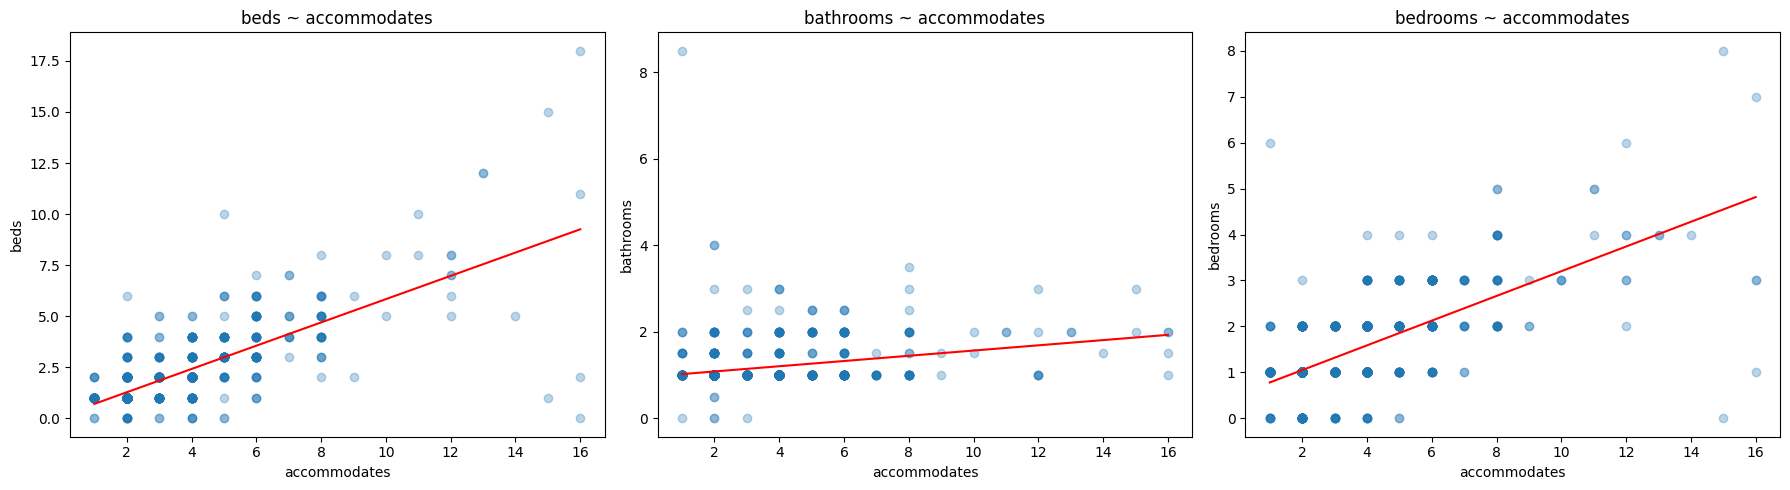

beds: y = 0.570 * accommodates + 0.136
bathrooms: y = 0.060 * accommodates + 0.963
bedrooms: y = 0.269 * accommodates + 0.512


In [209]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

features = ['beds', 'bathrooms', 'bedrooms']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, features):
    
    # dane bez NA
    tmp = df[['accommodates', col]].dropna()
    
    X = tmp[['accommodates']]
    y = tmp[col]
    
    model = LinearRegression()
    model.fit(X, y)
    
    # predykcje do wykresu
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    ax.scatter(X, y, alpha=0.3)
    ax.plot(x_line, y_line, color='red')
    
    ax.set_title(f'{col} ~ accommodates')
    ax.set_xlabel('accommodates')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# opcjonalnie współczynniki
for col in features:
    tmp = df[['accommodates', col]].dropna()
    model = LinearRegression().fit(tmp[['accommodates']], tmp[col])
    print(f"{col}: y = {model.coef_[0]:.3f} * accommodates + {model.intercept_:.3f}")

Otrzymane modele nie prezentują się najlepiej, więc spróbuję z random forest na podstawie tych wszystkich wartości + kolumna price


=== Model: bedrooms ===
R2: 0.8271
RMSE: 0.3567


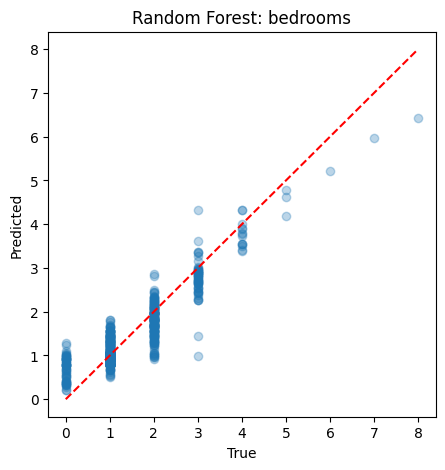


=== Model: beds ===
R2: 0.8615
RMSE: 0.6176


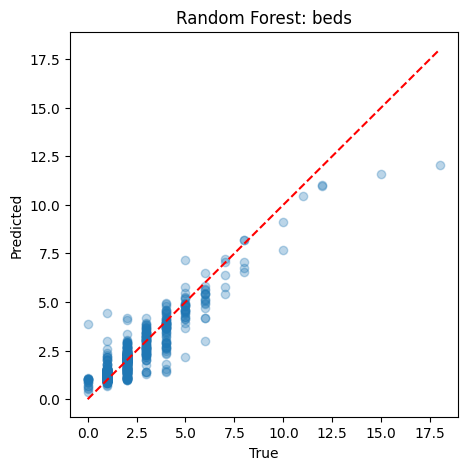


=== Model: bathrooms ===
R2: 0.7012
RMSE: 0.2607


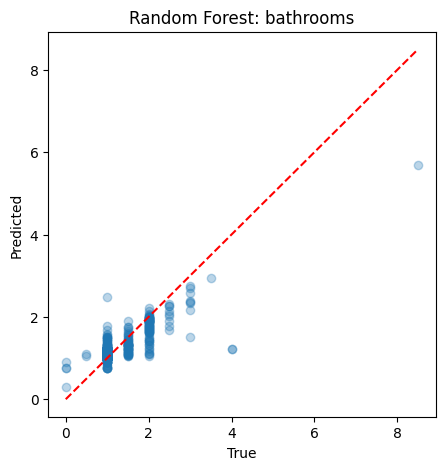

In [210]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

features_base = ['accommodates', 'beds', 'bedrooms', 'price']

models = {
    'bedrooms': ['accommodates', 'beds', 'price'],
    'beds': ['accommodates', 'bedrooms', 'price'],
    'bathrooms': ['accommodates', 'bedrooms', 'beds', 'price']
}

results = {}

for target, features in models.items():
    
    df_m = df[features + [target]].dropna()
    
    X = df_m[features]
    y = df_m[target]
    
    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None
    )
    
    rf.fit(X, y)
    pred = rf.predict(X)
    
    r2 = r2_score(y, pred)
    rmse = root_mean_squared_error(y, pred)

    results[target] = (r2, rmse)
    
    print(f"\n=== Model: {target} ===")
    print("R2:", round(r2, 4))
    print("RMSE:", round(rmse, 4))
    
    # wykres true vs pred
    plt.figure(figsize=(5,5))
    plt.scatter(y, pred, alpha=0.3)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Random Forest: {target}")
    plt.show()

Wartości zaproponowane przez random forest są lepsze niż z regresji liniowej

#### Imputacja danych

In [211]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# =========================
# MODELE (uczymy na pełnych danych)
# =========================

train_bedrooms = df[['accommodates', 'beds', 'price', 'bedrooms']].dropna()
model_bedrooms = RandomForestRegressor(n_estimators=200, random_state=42)
model_bedrooms.fit(train_bedrooms[['accommodates', 'beds', 'price']], train_bedrooms['bedrooms'])

train_beds = df[['accommodates', 'bedrooms', 'price', 'beds']].dropna()
model_beds = RandomForestRegressor(n_estimators=200, random_state=42)
model_beds.fit(train_beds[['accommodates', 'bedrooms', 'price']], train_beds['beds'])

train_bath = df[['accommodates', 'bedrooms', 'beds', 'price', 'bathrooms']].dropna()
model_bath = RandomForestRegressor(n_estimators=200, random_state=42)
model_bath.fit(train_bath[['accommodates', 'bedrooms', 'beds', 'price']], train_bath['bathrooms'])


# =========================
# ITERACYJNA IMPUTACJA
# =========================

for _ in range(2):  # 2 iteracje wystarczą zwykle
    # bedrooms
    mask = df['bedrooms'].isna()
    if mask.sum() > 0:
        df.loc[mask, 'bedrooms'] = model_bedrooms.predict(
            df.loc[mask, ['accommodates', 'beds', 'price']]
        )

    # beds
    mask = df['beds'].isna()
    if mask.sum() > 0:
        df.loc[mask, 'beds'] = model_beds.predict(
            df.loc[mask, ['accommodates', 'bedrooms', 'price']]
        )

    # bathrooms
    mask = df['bathrooms'].isna()
    if mask.sum() > 0:
        df.loc[mask, 'bathrooms'] = model_bath.predict(
            df.loc[mask, ['accommodates', 'bedrooms', 'beds', 'price']]
        )

#### Usunięcie wierszy z brakami w kolumnach mających po 1 brakującej wartości

In [212]:
cols = [
    'host_listings_count',
    'host_has_profile_pic',
    'host_total_listings_count',
    'host_identity_verified',
    'host_since'
]

df = df.dropna(subset=cols)

Sprawdzenie ile jeszcze NA zostało

In [213]:
na_counts = df.isna().sum()

# filtr tylko kolumn z NA > 0
na_counts = na_counts[na_counts > 0]

# ładna tabelka
na_table = (
    na_counts
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_values'})
    .sort_values('missing_values', ascending=False)
)

print("Braki danych po imputacji:")
print(na_table)

assert df['bedrooms'].isna().sum() == 0, "Są nadal braki w bedrooms"

Braki danych po imputacji:
Empty DataFrame
Columns: [column, missing_values]
Index: []


### Wszystkie brakujące wartości zostały rozwiązane

Usunięcie id ze zbioru danych

In [214]:
df=df.drop('id', axis=1)

### Histogramy każdej z kolumn

Część danych ma naturę logaytmiczną więc użyję dla nich funkcji log1p - bo mogą też zawierać 0.

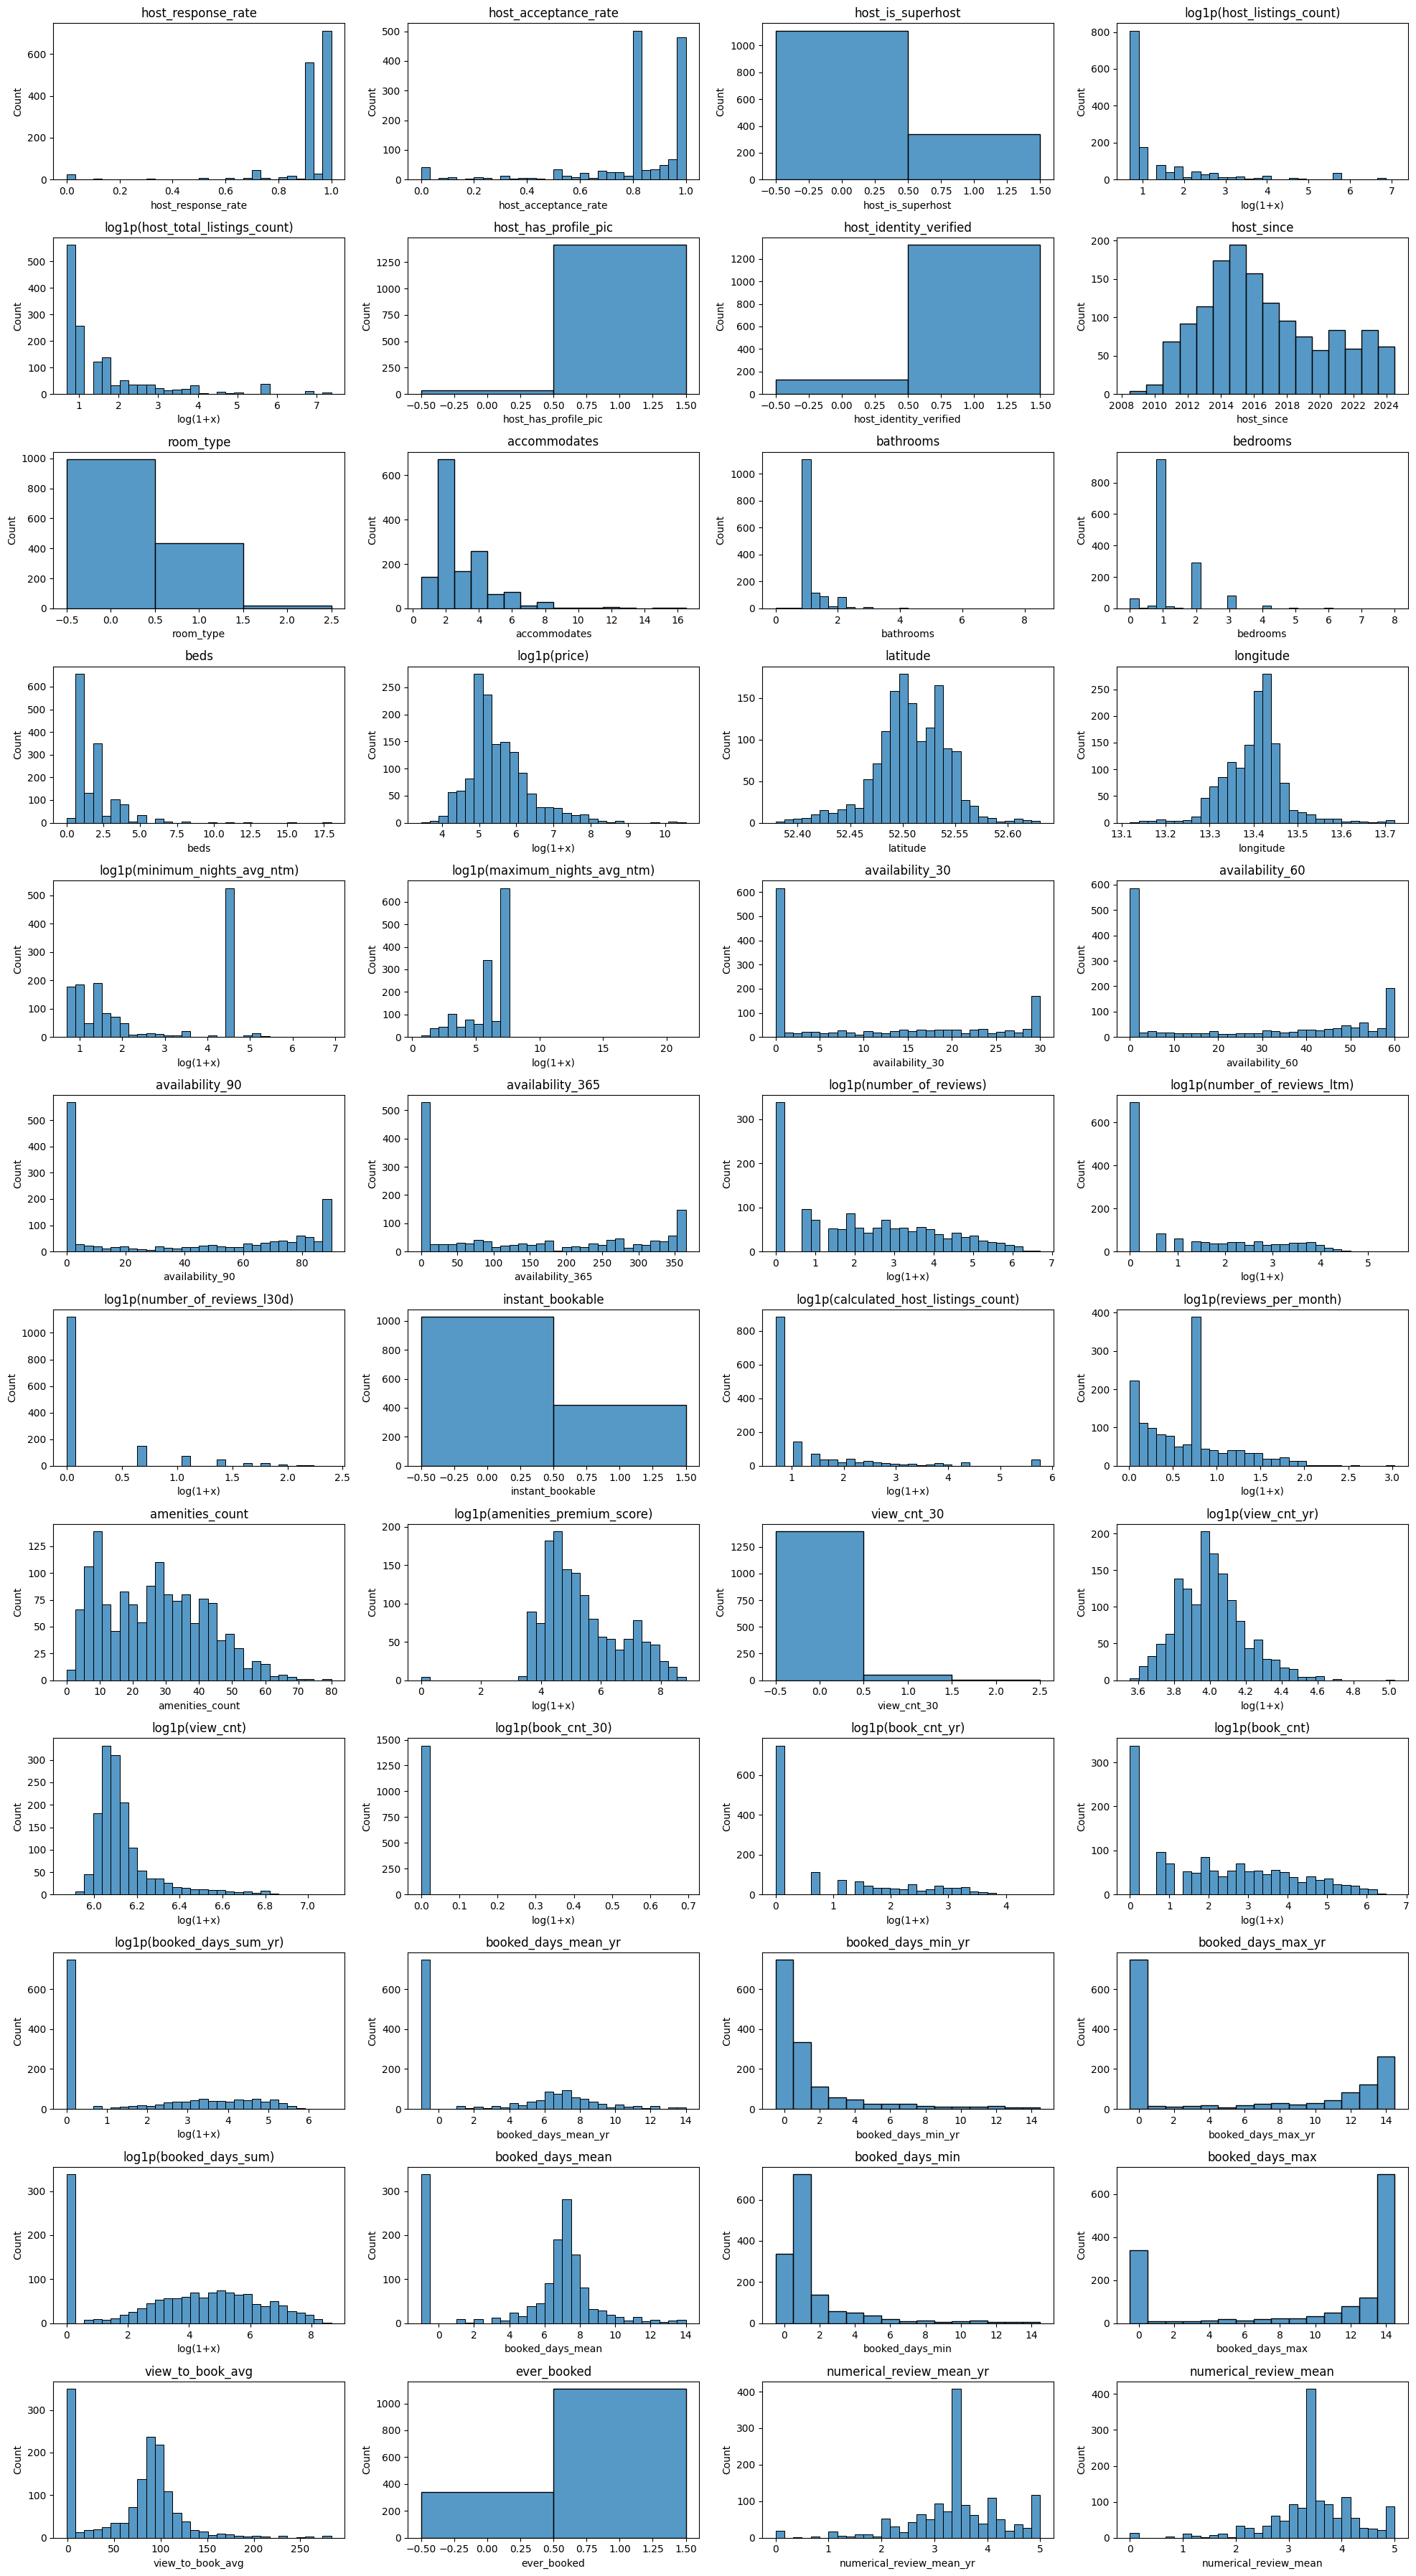

In [215]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# kolumny z transformacją log1p
log_cols = {
    "host_listings_count",
    "host_total_listings_count",
    "price",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "calculated_host_listings_count",
    "reviews_per_month",
    "amenities_premium_score",
    "view_cnt",
    "view_cnt_yr",
    "book_cnt_yr",
    "book_cnt",
    "book_cnt_30",
    "booked_days_sum_yr",
    "booked_days_sum",
}

num_cols = df.select_dtypes(include=["number"]).columns

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 3))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    data = df[col]

    if col in log_cols:
        # usuń ewentualne wartości ujemne
        data = data[data >= 0]

        sns.histplot(np.log1p(data), bins=30)
        plt.title(f"log1p({col})")
        plt.xlabel("log(1+x)")

    else:
        if data.nunique() < 20:
            sns.histplot(data, bins=data.nunique(), discrete=True)
        else:
            sns.histplot(data, bins=30)

        plt.title(col)

plt.tight_layout()
plt.show()

### Normalizacja danych

Część danych ma naturę logarytmiczną np. kolumny z "count" i będzie to uwzględnione.  
Dane binarne pozostaną bez zmian.  
Pozosałe kolumny (ciągłe lub dyskretne) zostaną poddane standaryzacji

In [216]:
log_cols = {
    "host_listings_count",
    "host_total_listings_count",
    "price",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "calculated_host_listings_count",
    "reviews_per_month",
    "amenities_premium_score",
    "view_cnt",
    "view_cnt_yr",
    "book_cnt_yr",
    "book_cnt",
    "book_cnt_30",
    "booked_days_sum_yr",
    "booked_days_sum",
}

bin_cols = {
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable",
    "ever_booked",
}

other_cols = [col for col in df.columns if col not in bin_cols and col not in log_cols]

from sklearn.preprocessing import StandardScaler
import joblib

# log1p
df[list(log_cols)] = np.log1p(df[list(log_cols)])

# standaryzacja
scaler = StandardScaler()

df[other_cols] = scaler.fit_transform(
    df[other_cols]
)

feature_names = df.columns.tolist()

artifacts = {
    "scaler": scaler,
    "feature_names": feature_names,
    "amenity_freq": amenity_freq.to_dict(),  # słownik amenity -> frequency
    "other_cols": list(other_cols),
    "bin_cols": list(bin_cols),
    "log_cols": list(log_cols),
}

joblib.dump(artifacts, "generated/artifacts.joblib");

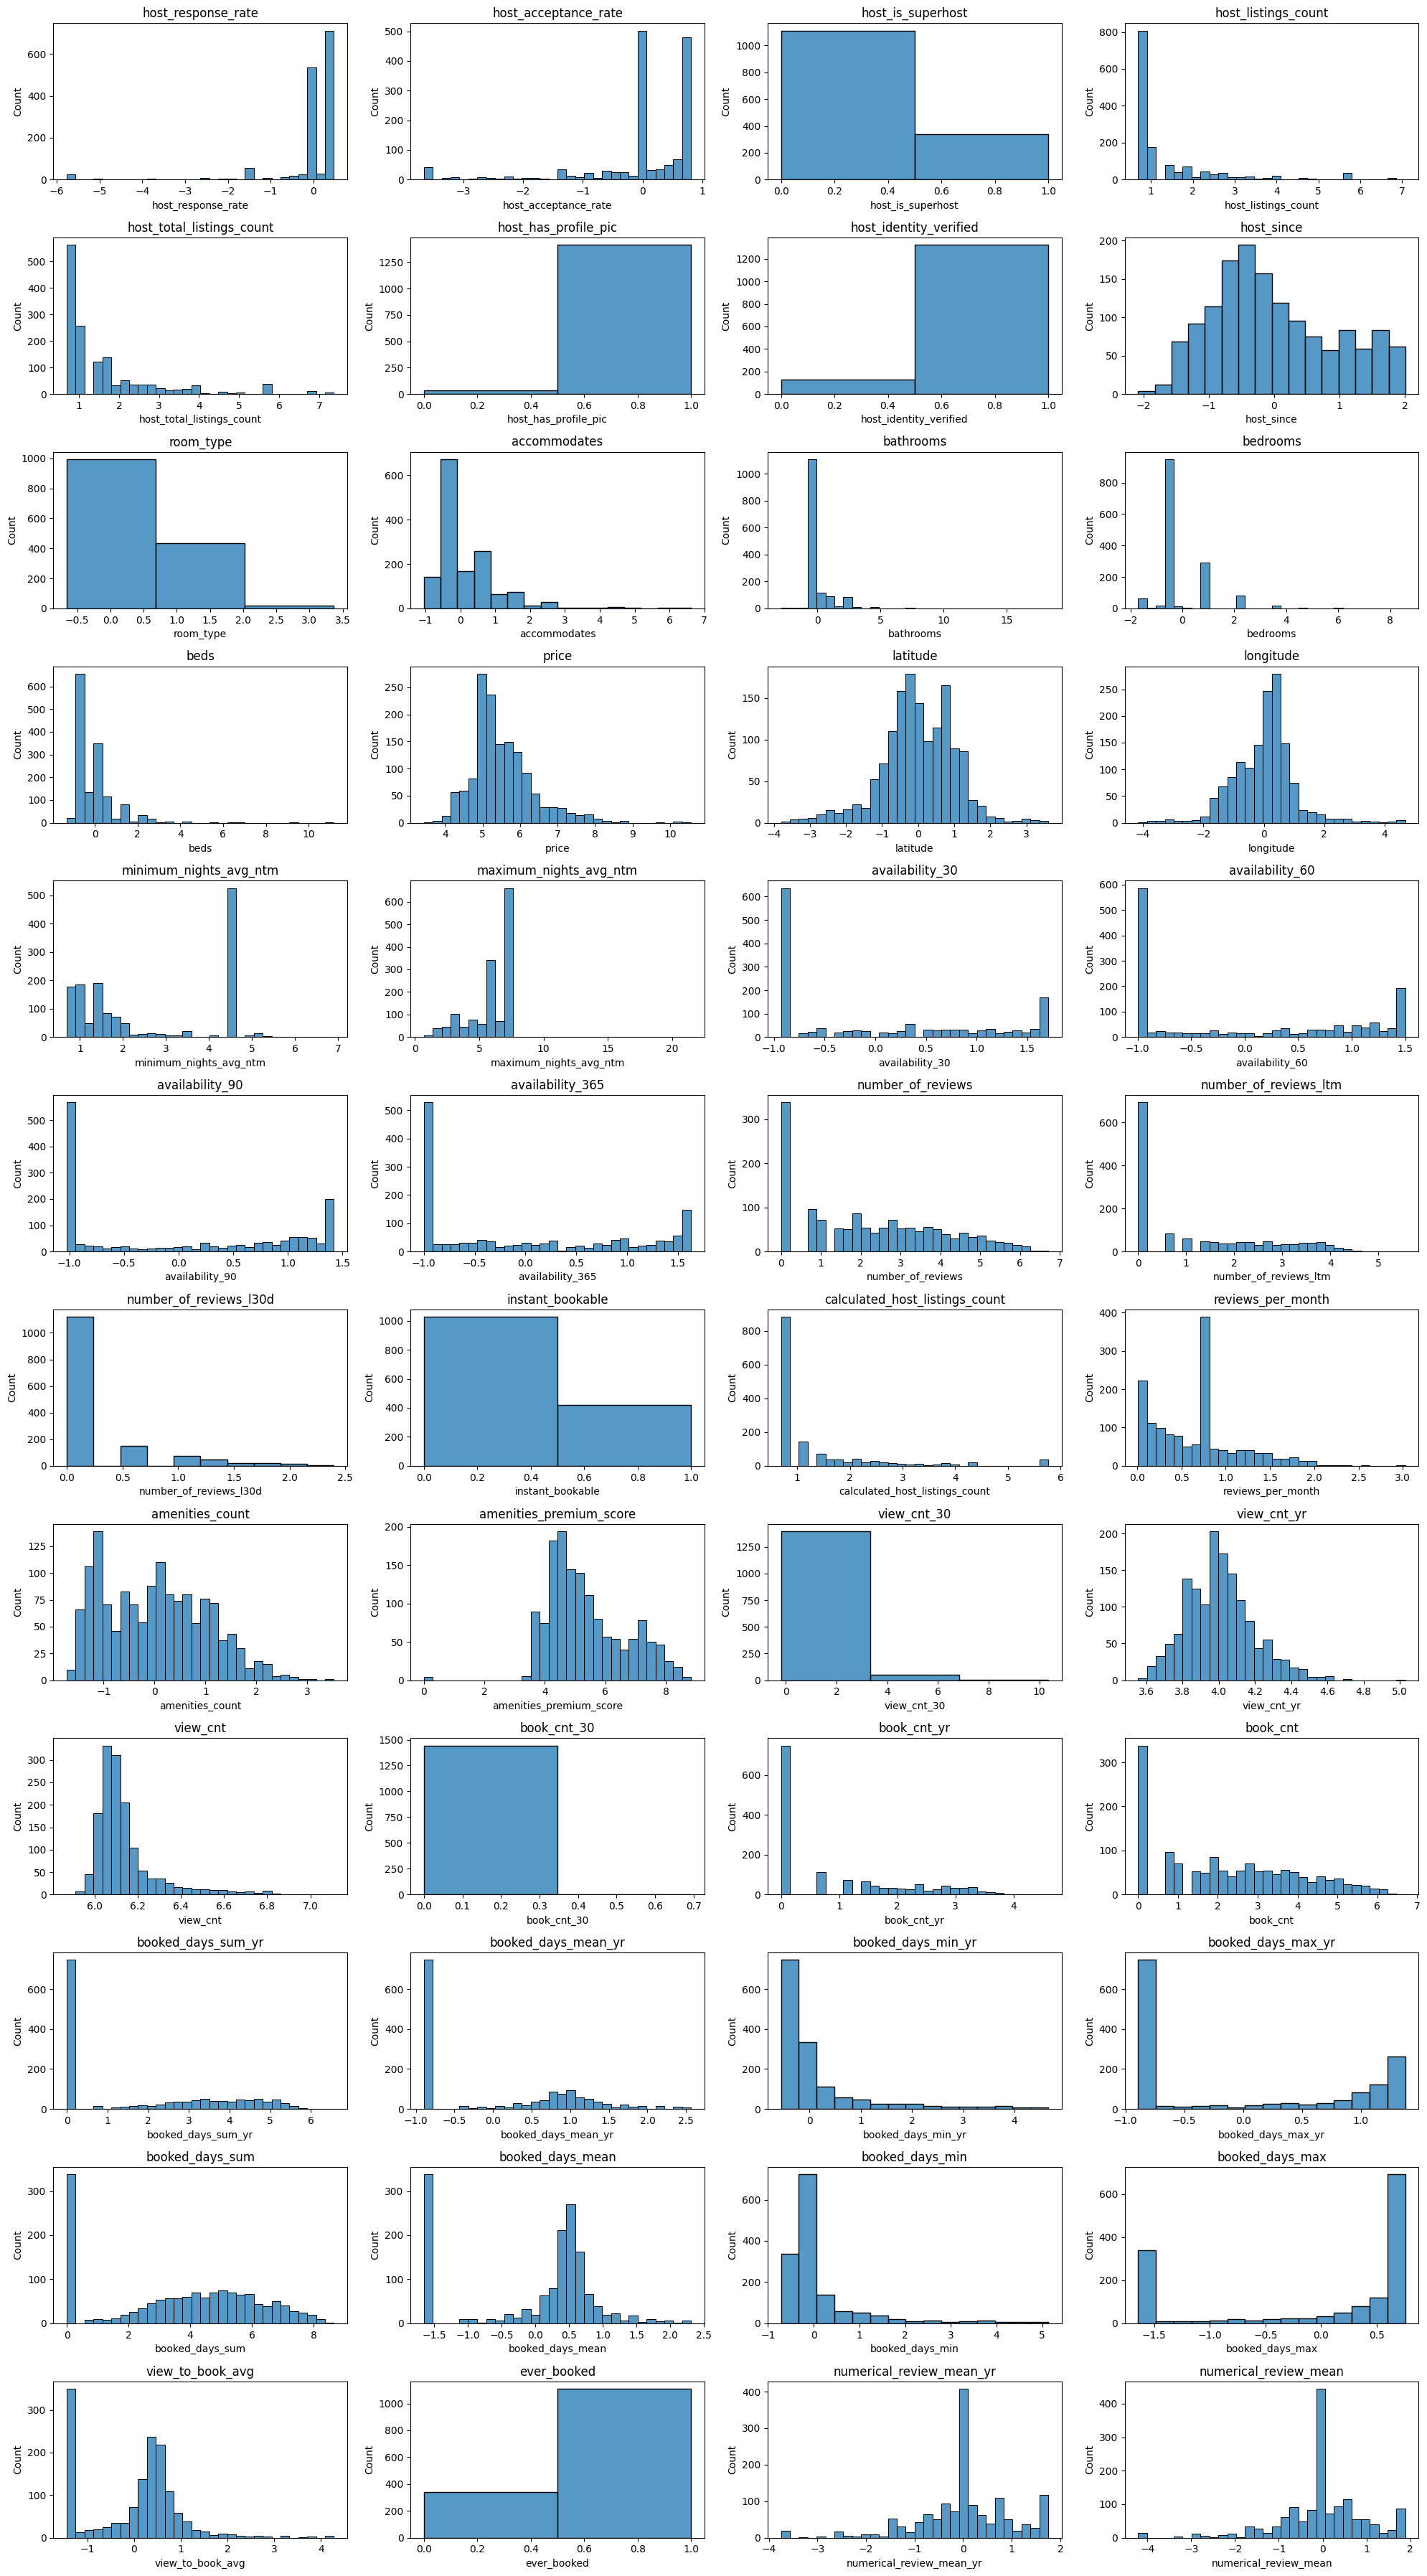

In [217]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=["number"]).columns

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 3))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    data = df[col]

    if data.nunique() < 20:
        sns.histplot(data, bins=data.nunique(), discrete=False)
    else:
        sns.histplot(data, bins=30)

    plt.title(col)

plt.tight_layout()
plt.show()

### Korelacje

In [218]:
import pandas as pd
import numpy as np

# =========================
# kolumny binarne
# =========================
bin_cols = {
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable",
    "ever_booked",
}

# =========================
# wybór kolumn
# =========================
all_cols = df.select_dtypes(include=[np.number]).columns

continuous_cols = [c for c in all_cols if c not in bin_cols and c != "room_type"]
numerical_cols = [c for c in all_cols if c not in bin_cols]

#### Korelacja Pearsona między atrybutami ciągłymi

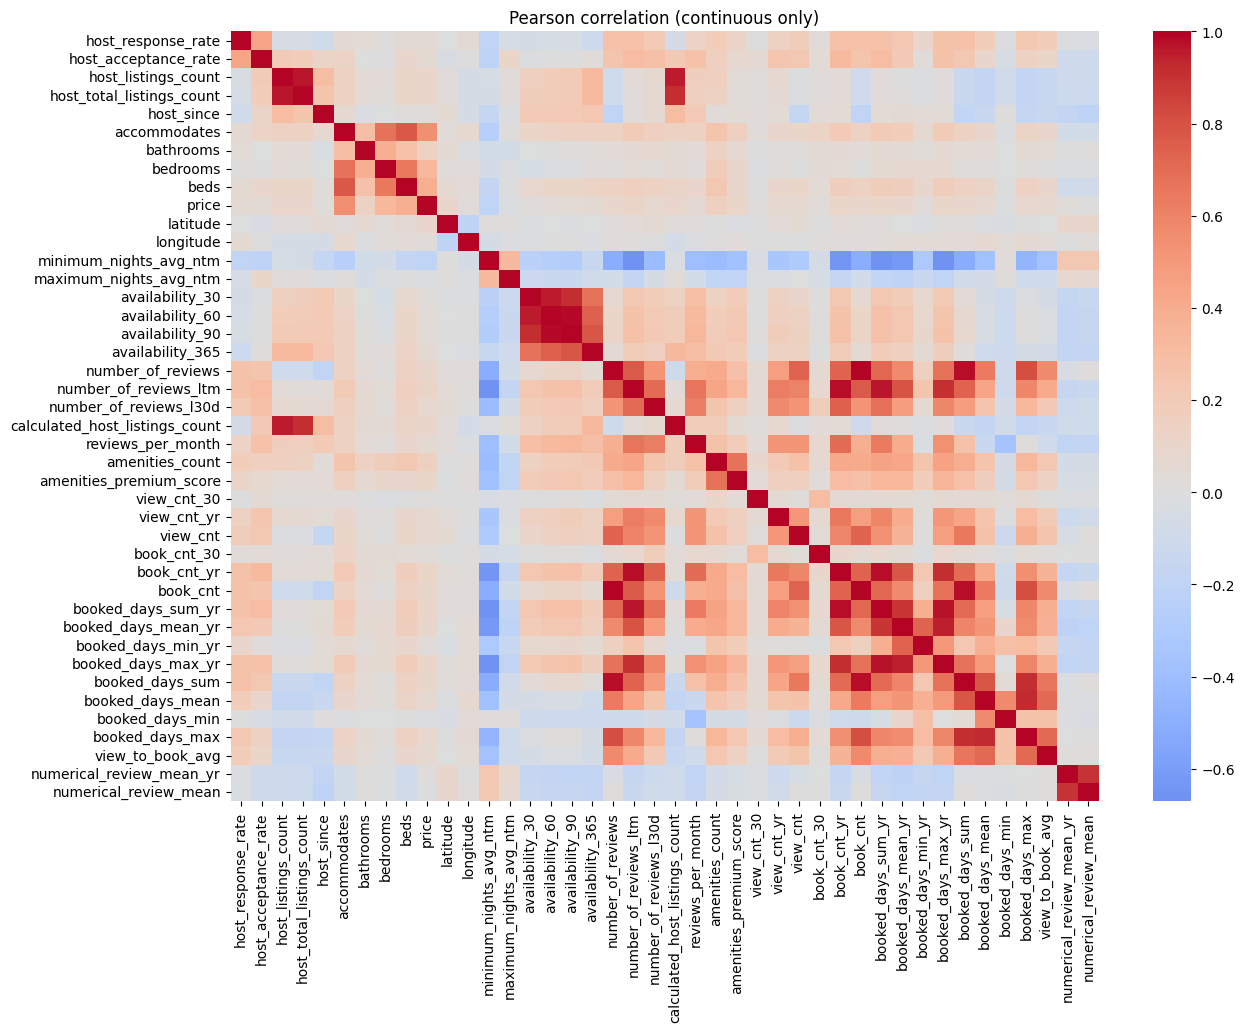

In [219]:
pearson_corr = df[continuous_cols].corr(method="pearson")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0)
plt.title("Pearson correlation (continuous only)")
plt.show()

#### Korelacja Spearmana między atrybutami numerycznymi

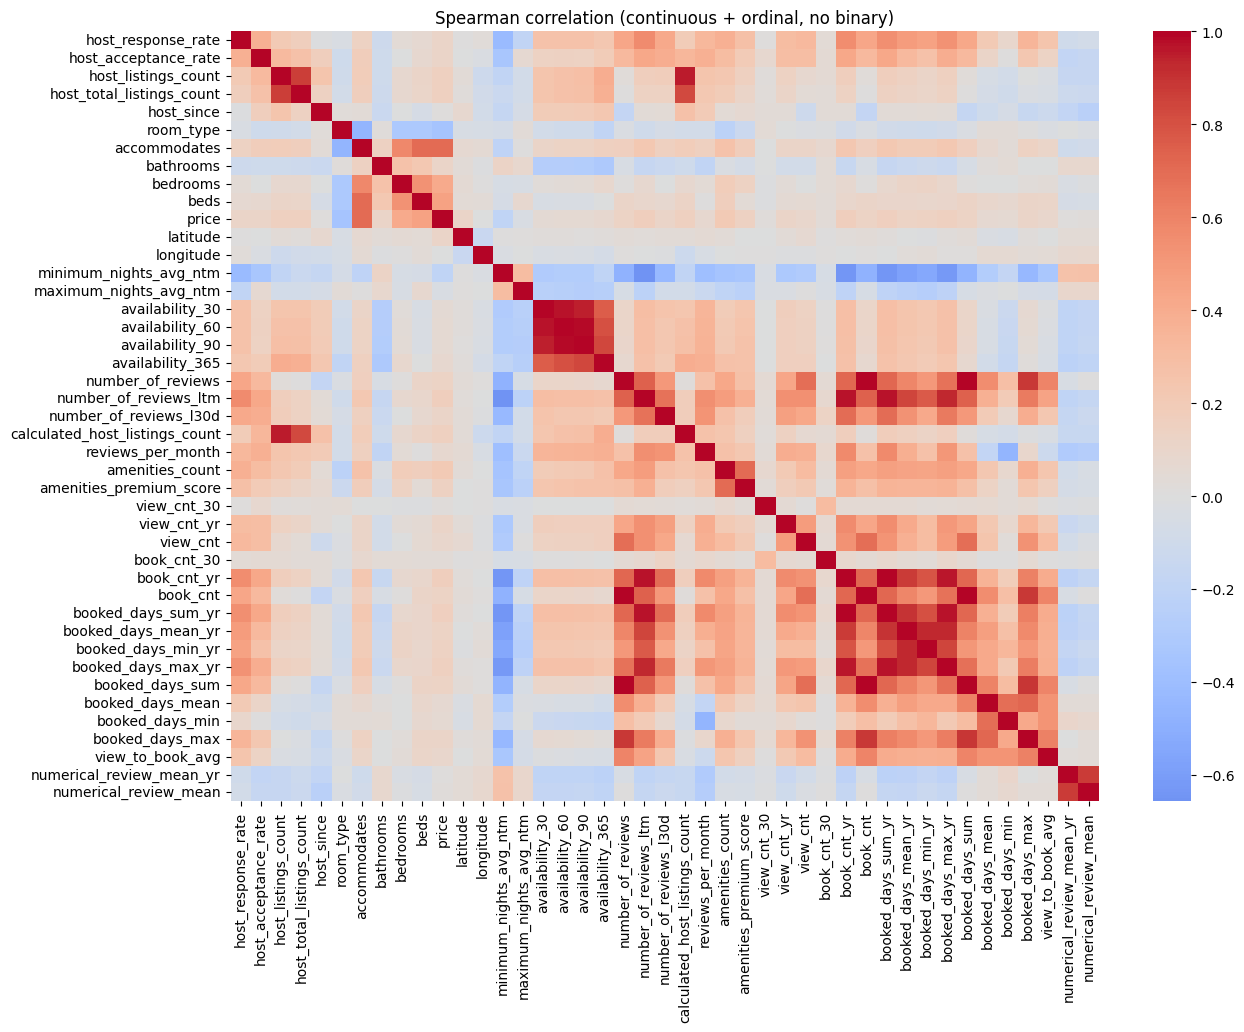

In [220]:
spearman_corr = df[numerical_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0)
plt.title("Spearman correlation (continuous + ordinal, no binary)")
plt.show()

#### Usunięcie skorelowanych kolumn i ponowne wyświetlenie korealcji

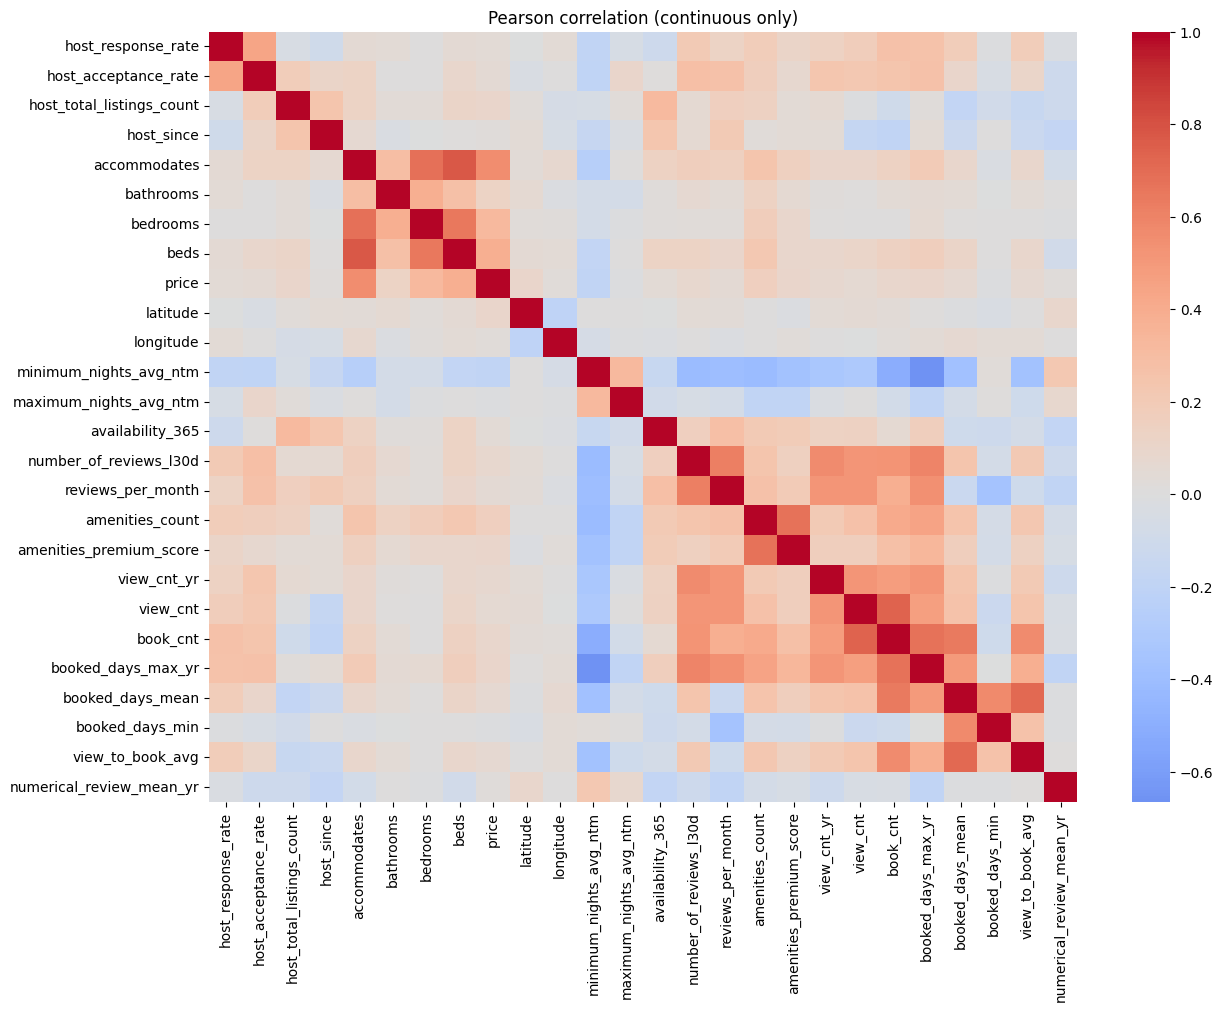

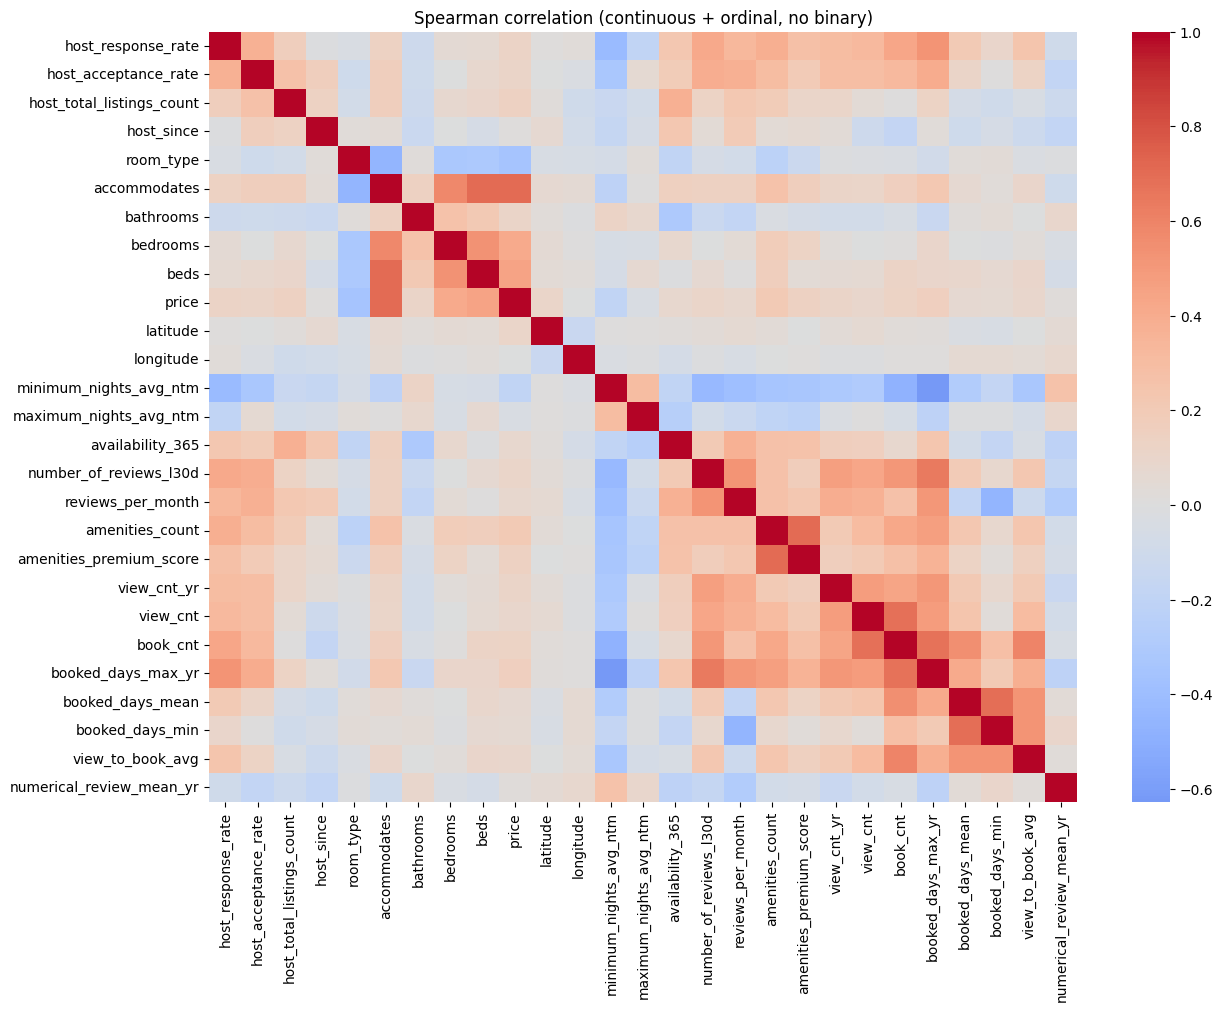

In [221]:
cols_to_drop_correlation = {
    "host_listings_count",
    "calculated_host_listings_count",
    "availability_30",
    "availability_60",
    "availability_90",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "book_cnt_30",
    "book_cnt_yr",
    "booked_days_sum_yr",
    "booked_days_mean_yr",
    "booked_days_min_yr",
    "booked_days_sum",
    "booked_days_max",
    "numerical_review_mean",
}

cols_to_drop_useless = {
    "view_cnt_30",
    "host_has_profile_pic"
}

df = df.drop(columns=cols_to_drop_correlation.union(cols_to_drop_useless), errors='ignore')

import pandas as pd
import numpy as np

# =========================
# kolumny binarne
# =========================
bin_cols = {
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable",
    "ever_booked",
}

# =========================
# wybór kolumn
# =========================
all_cols = df.select_dtypes(include=[np.number]).columns

continuous_cols = [c for c in all_cols if c not in bin_cols and c != "room_type"]
numerical_cols = [c for c in all_cols if c not in bin_cols]

pearson_corr = df[continuous_cols].corr(method="pearson")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0)
plt.title("Pearson correlation (continuous only)")
plt.show()

spearman_corr = df[numerical_cols].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0)
plt.title("Spearman correlation (continuous + ordinal, no binary)")
plt.show()

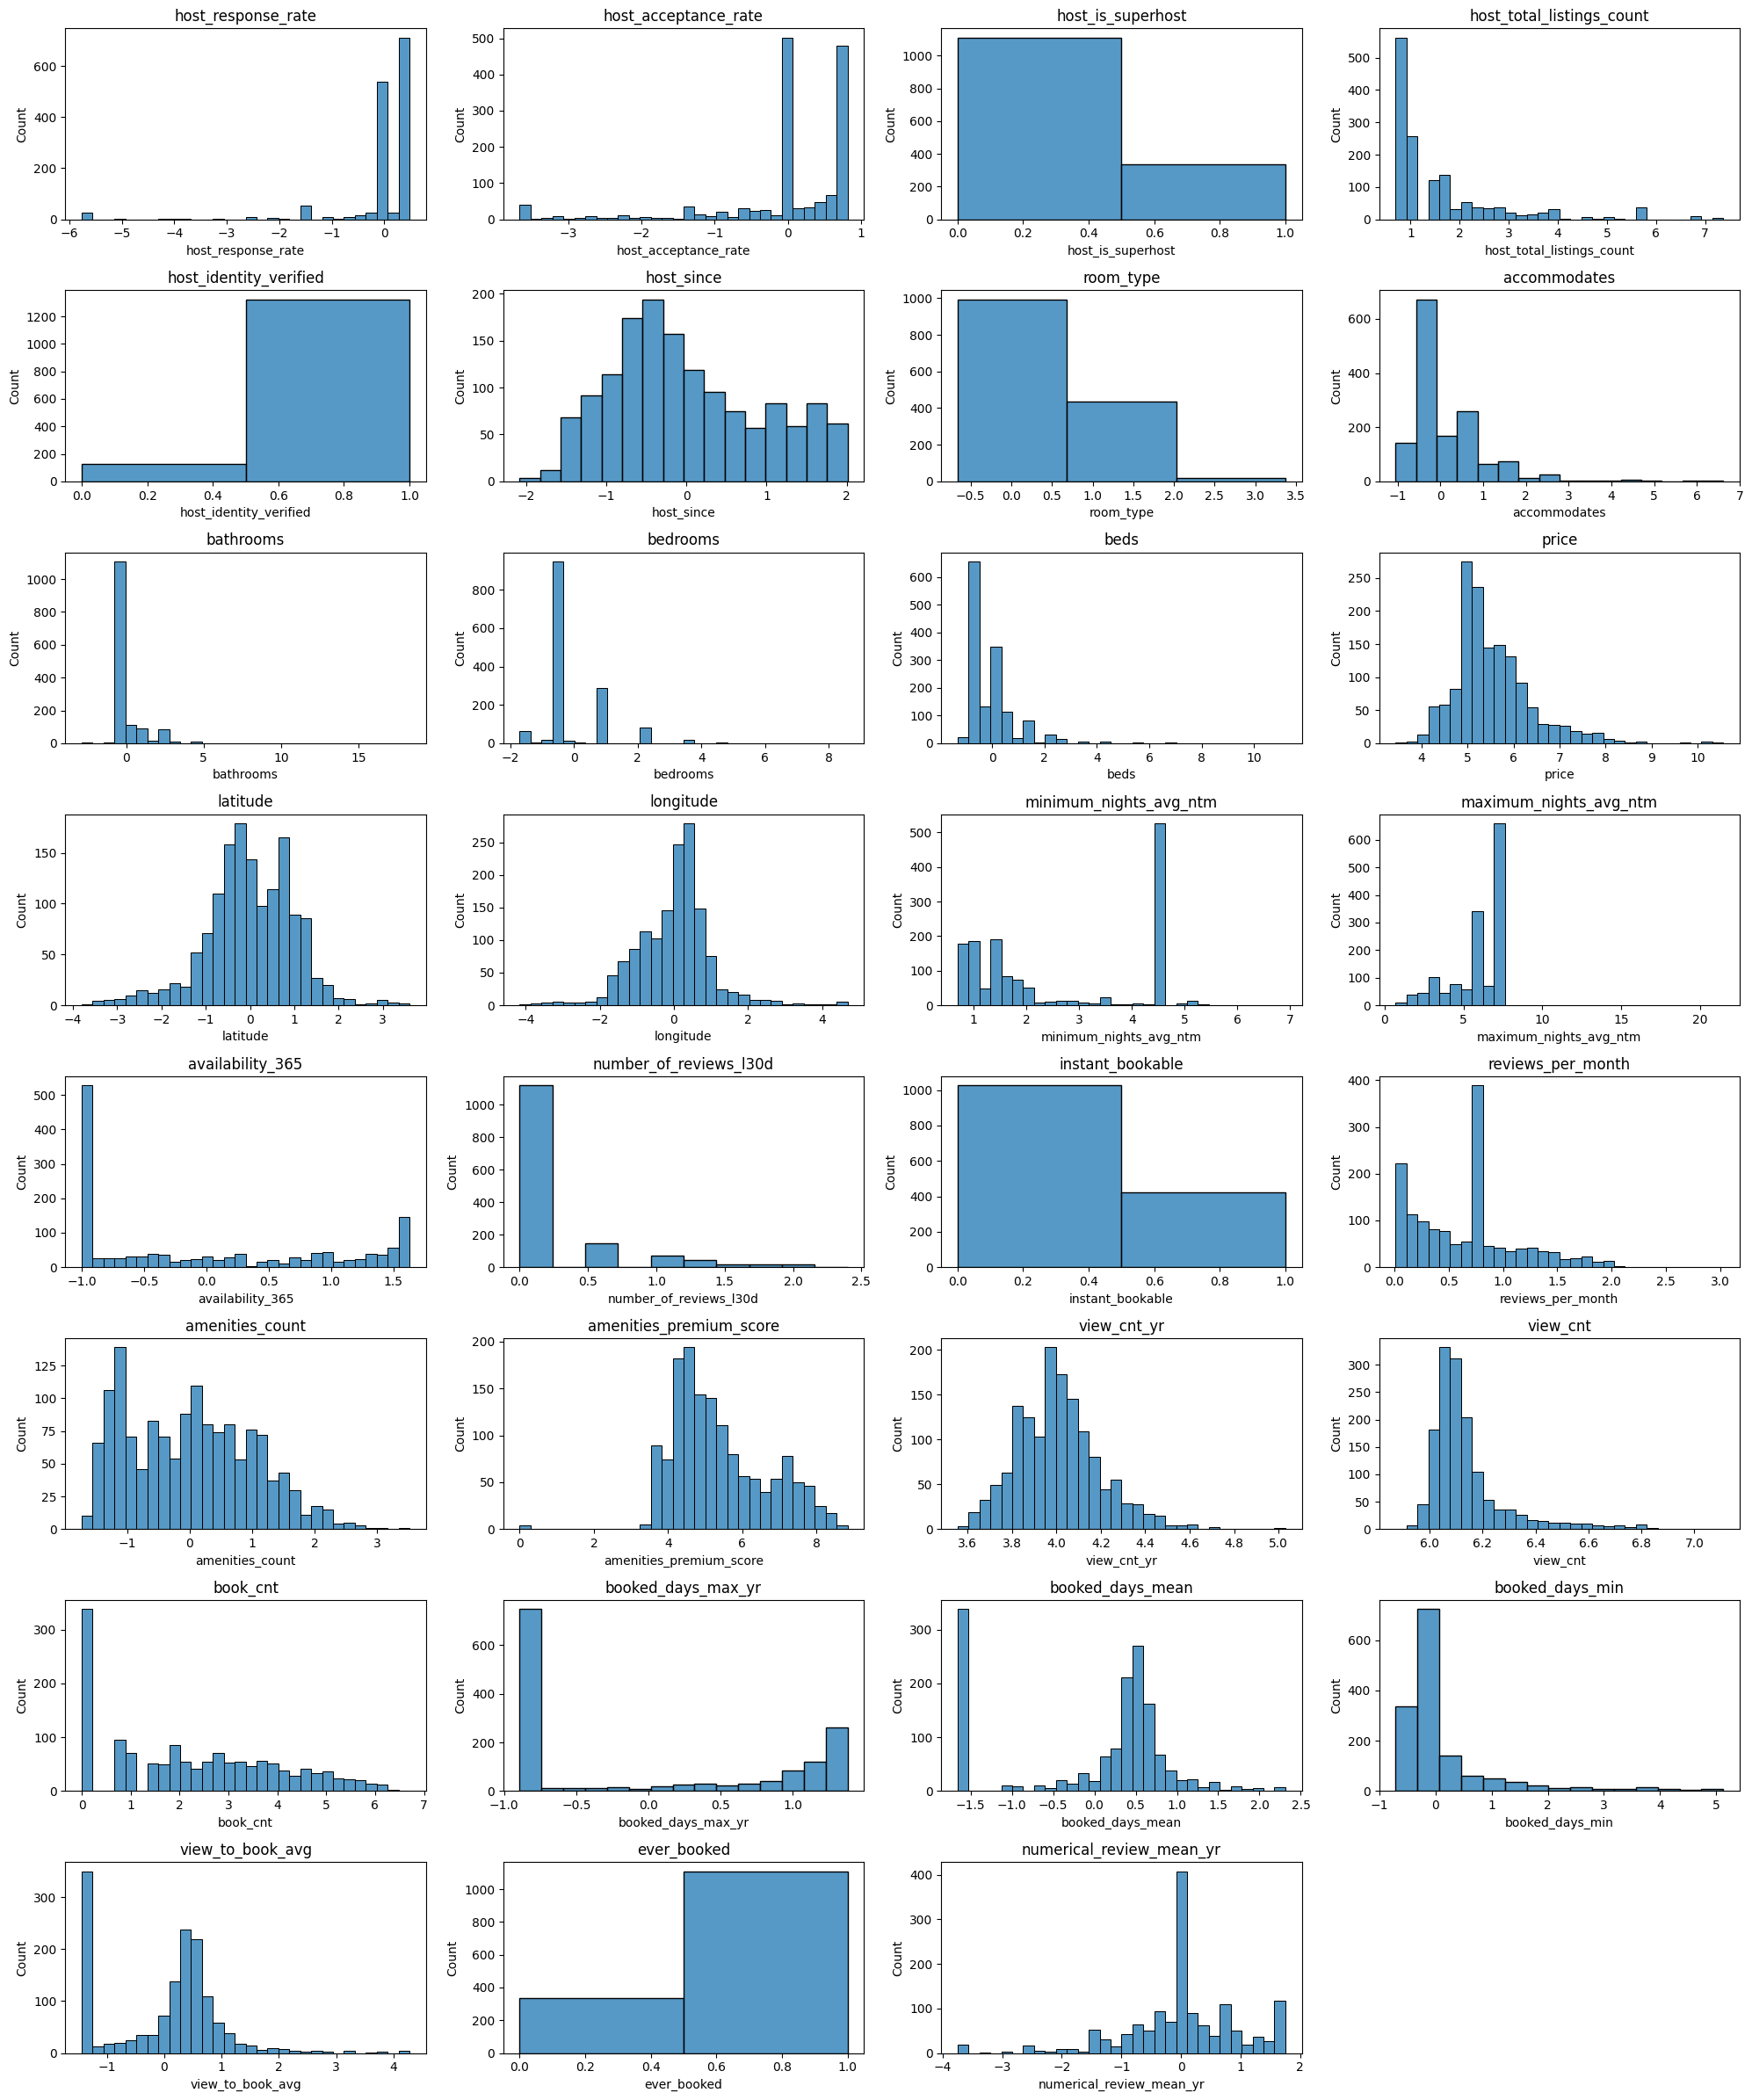

In [222]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=["number"]).columns

n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 3))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    data = df[col]

    if data.nunique() < 20:
        sns.histplot(data, bins=data.nunique(), discrete=False)
    else:
        sns.histplot(data, bins=30)

    plt.title(col)

plt.tight_layout()
plt.show()

### Oznaczanie anomalii

Pogrupuję wszystkie pokoje na podstawie wszystkich kolumn poza "price" algorytmem k-means. Następnie w każdym klastrze wykryję zawyżone ceny miarą MAD (Median Absolute Deviation) i dodam do zbioru danych atrybut "overpriced".

#### Klasteryzacja

Poszukiwanie odpowiedniej liczby klastrów

/tmp/ipykernel_41589/1467720289.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


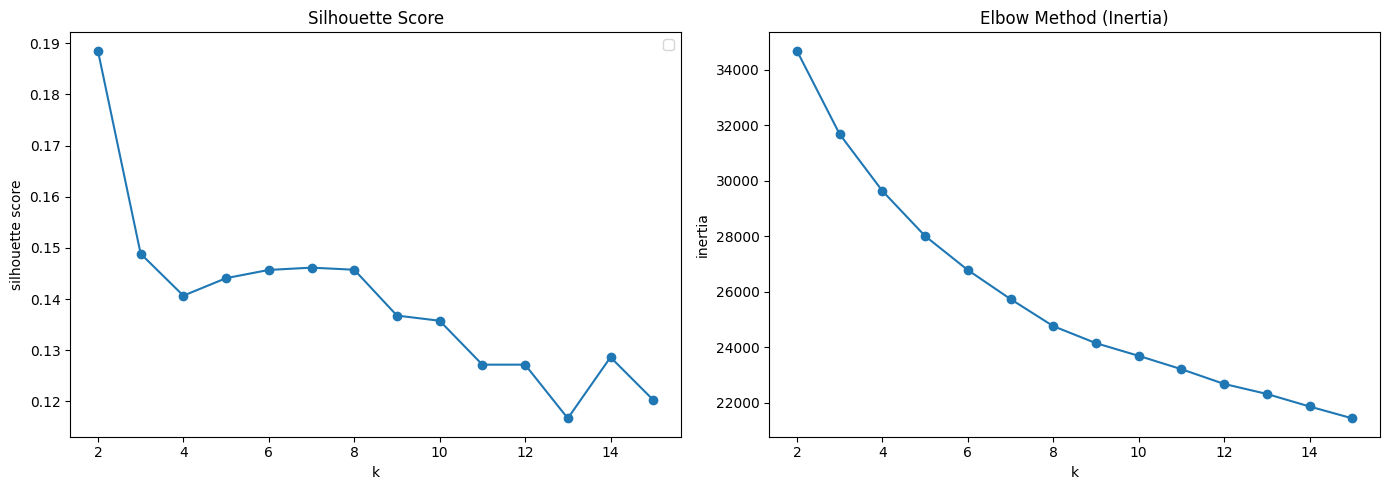

In [223]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

X = df.drop(columns=["price"]).copy()

inertia = []
sil_scores = []

K_range = range(2, 16)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    inertia.append(model.inertia_)

    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Silhouette Score ---
ax[0].plot(K_range, sil_scores, marker="o")
ax[0].set_title("Silhouette Score")
ax[0].set_xlabel("k")
ax[0].set_ylabel("silhouette score")

# best_k_sil = K_range[np.argmax(sil_scores)]
# ax[0].axvline(best_k_sil, color="red", linestyle="--", label=f"best k={best_k_sil}")
ax[0].legend()

# --- Elbow (inertia) ---
ax[1].plot(K_range, inertia, marker="o")
ax[1].set_title("Elbow Method (Inertia)")
ax[1].set_xlabel("k")
ax[1].set_ylabel("inertia")

plt.tight_layout()
plt.show()

Wykres inercji nie pokazuje żadnego punktu przegięcia, zaś Silhuoette Score ma płaszczyznę dla k = 6..8 (pomijając większe wartości dla k= 2 lub 3), więc wybiorę k=8 jako liczbę klastrów.

#### Wykrycie anomalii metryką MAD

Za anomalię uznam price > median + 2 * median(|price - median|)

Liczba klastrów: 8


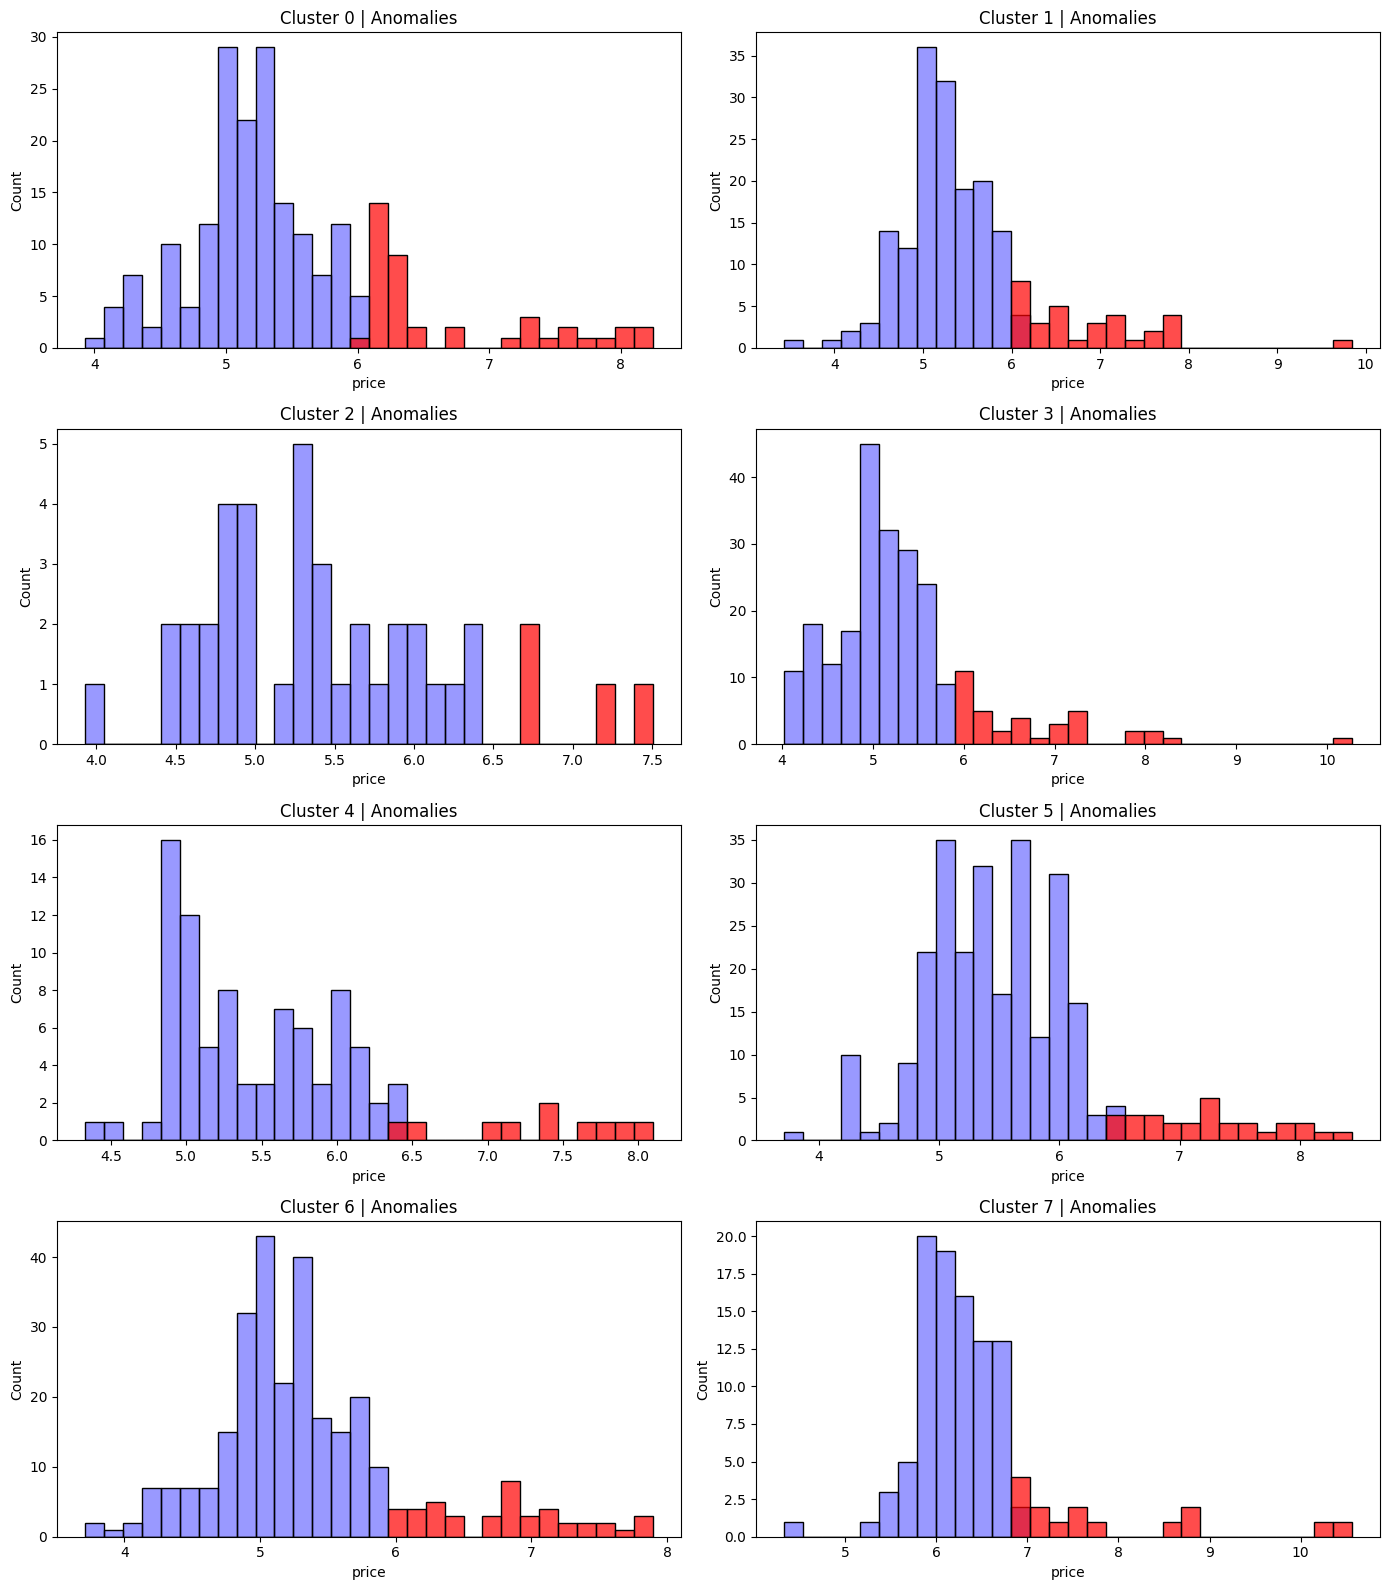

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(X)

print("Liczba klastrów:", df["cluster"].nunique())


def plot_cluster_price(metric_col, title):
    clusters = sorted(df["cluster"].unique())

    n = len(clusters)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(14, rows * 4))

    for i, c in enumerate(clusters):
        plt.subplot(rows, cols, i + 1)

        data = df[df["cluster"] == c]

        anomalies = data[data[metric_col] == 1]
        no_anomalies = data[data[metric_col] == 0]

        min_price = data["price"].min()
        max_price = data["price"].max()

        binrange = (min_price, max_price)
        bins = 30

        sns.histplot(
            no_anomalies["price"],
            bins=bins,
            binrange=binrange,
            color="blue",
            alpha=0.4
        )

        sns.histplot(
            anomalies["price"],
            bins=bins,
            binrange=binrange,
            color="red",
            alpha=0.7
        )

        plt.title(f"Cluster {c} | {title}")
        plt.xlabel("price")

    plt.tight_layout()
    plt.show()

median = df.groupby("cluster")["price"].transform("median")
mad = df.groupby("cluster")["price"].transform(
    lambda x: np.median(np.abs(x - np.median(x)))
)

df["overpriced"] = ((df["price"] > (median + 2 * mad))).astype(int)

plot_cluster_price("overpriced", "Anomalies")

#### Statystyki anomalii

In [225]:
summary = (
    df.groupby("cluster")['overpriced']
    .agg(
        total="size",
        anomalies="sum"
    )
    .assign(
        anomaly_percent=lambda x: round(x["anomalies"] / x["total"] * 100, 2)
    )
)
print(summary)

print("\nŁącznie dla całego zbioru danych:")
print(f"Całkowita liczba przykładów: {df['overpriced'].count()}")
print(f"Całkowita liczba anomalii: {df['overpriced'].sum()}")
print(f"Procent anomalii: {round(df['overpriced'].mean() * 100, 2)}%")

df=df.drop('cluster', axis=1)

         total  anomalies  anomaly_percent
cluster                                   
0          210         41            19.52
1          190         32            16.84
2           40          4            10.00
3          234         37            15.81
4           94         10            10.64
5          281         29            10.32
6          291         44            15.12
7          108         15            13.89

Łącznie dla całego zbioru danych:
Całkowita liczba przykładów: 1448
Całkowita liczba anomalii: 212
Procent anomalii: 14.64%


### Selekcja atrybutów

#### Współczynniki informatywności wzajemnej względem atrybutów price oraz overpriced

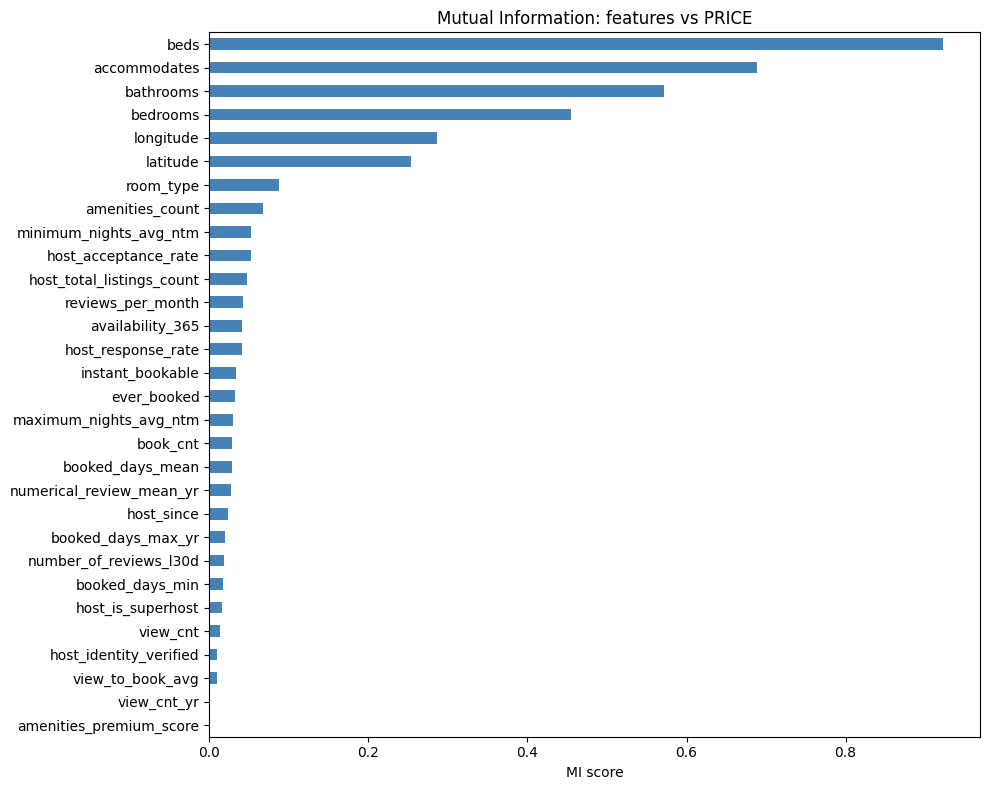

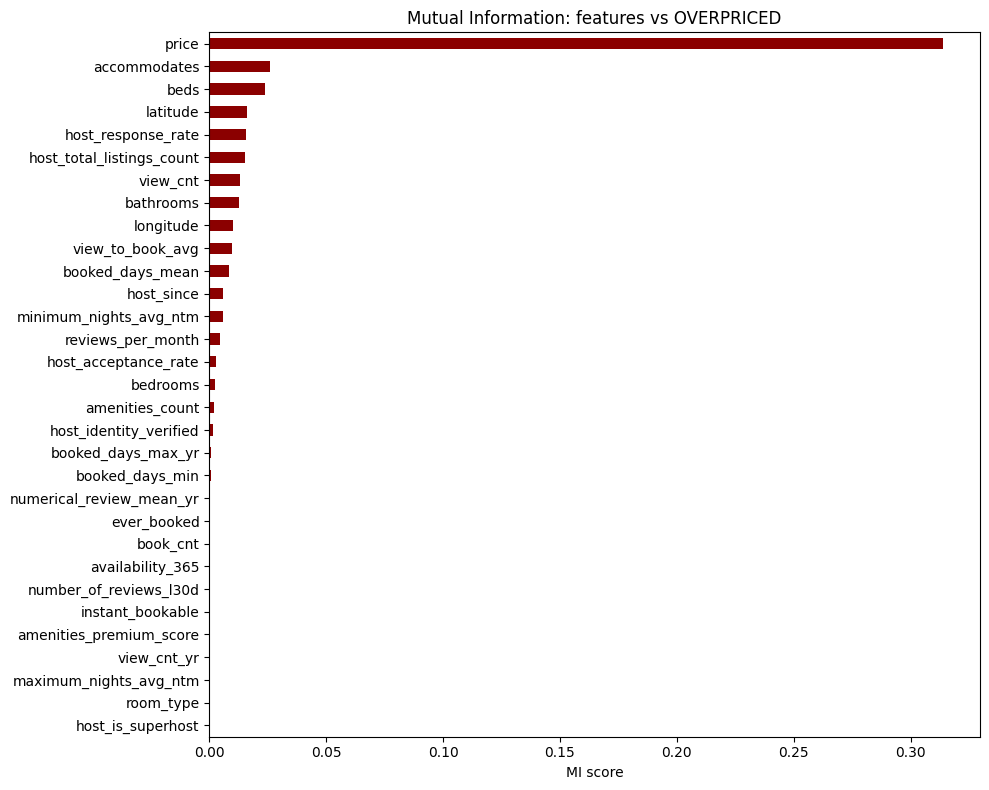

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

# =========================
# przygotowanie danych
# =========================

df_mi = df.copy()

# targety
y_price = df_mi["price"]

y_over = df_mi["overpriced"].astype(int)

# feature set (bez targetów)
X1 = df_mi.drop(columns=["price", "overpriced"])
X2 = df_mi.drop(columns=["overpriced"])

# =========================
# 1. MI vs price (regression)
# =========================

mi_price = mutual_info_regression(X1, y_price, random_state=42)

mi_price_series = pd.Series(mi_price, index=X1.columns).sort_values(ascending=True)

# =========================
# 2. MI vs overpriced (classification)
# =========================

mi_over = mutual_info_classif(X2, y_over, random_state=42)

mi_over_series = pd.Series(mi_over, index=X2.columns).sort_values(ascending=True)

# =========================
# PLOT 1: vs price
# =========================

plt.figure(figsize=(10, 8))
mi_price_series.plot(kind="barh", color="steelblue")
plt.title("Mutual Information: features vs PRICE")
plt.xlabel("MI score")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: vs overpriced
# =========================

plt.figure(figsize=(10, 8))
mi_over_series.plot(kind="barh", color="darkred")
plt.title("Mutual Information: features vs OVERPRICED")
plt.xlabel("MI score")
plt.tight_layout()
plt.show()

#### Końcowe zbiory danych

Utworzenie 2 zbiorów danych:
1. production_dataset.csv zawierającego dane o pokojach dostępne w momencie tworzenia oferty; etykietowany anomaliami
2. historical_dataset.csv zawierającego dane również "z przyszłości" przydatnego, przy tworzeniu modeli operujących na hisotrycznych danych


Usunięcie kilku najmniej informatywnych kolumn oraz tych, które nie będą dostępne na produkcji (przecieki)

In [227]:
cols_non_available_on_production = {
    "booked_days_max_yr",
    "view_to_book_avg",
    "view_cnt",
    "booked_days_min",
    "booked_days_mean",
    "book_cnt",
    "maximum_nights_avg_ntm",
    "minimum_nights_avg_ntm",
    "reviews_per_month",
    "number_of_reviews_l30d",
    "ever_booked",
    "numerical_review_mean_yr",
    "view_cnt_yr",
    "availability_365",
}

non_informative_cols = {
    "host_is_superhost",
    "host_identity_verified",
    "instant_bookable",
    "host_since",
    "numerical_review_mean_yr",
    "number_of_reviews_l30d",
    "view_cnt_yr",
    "booked_days_mean",
    "maximum_nights_avg_ntm",
}


historical_df = df.drop(columns=non_informative_cols)
historical_df.to_csv('data/historical_dataset.csv', index=False)

production_df = df.drop(columns=cols_non_available_on_production.union(non_informative_cols))
production_df.to_csv('data/production_dataset.csv', index=False)

Zbiory treningowe zostały utowrzone

## Utworzenie prostych modeli

Utworzę 2 proste modele (Random Forest z kros-walidacją) w celu oceny, jak dobrze są w stanie zamodelować zadania:
- detekcji anomalii na wszystkich danych
- detekcji anomalii na dostępnych tylko na produkcji

Ponadto policzę metryki: dokładność, precyzja i czułość oraz pokażę macierz pomyłek

Historical Dataset fold=1 | Accuracy=0.979 Precision=1.000 Recall=0.857 Specifity=1.000
Historical Dataset fold=2 | Accuracy=0.966 Precision=0.946 Recall=0.814 Specifity=0.992
Historical Dataset fold=3 | Accuracy=0.969 Precision=0.972 Recall=0.814 Specifity=0.996
Historical Dataset fold=4 | Accuracy=0.955 Precision=0.914 Recall=0.762 Specifity=0.988
Historical Dataset fold=5 | Accuracy=0.941 Precision=0.931 Recall=0.643 Specifity=0.992

Historical Dataset
Accuracy   : 0.962 ± 0.013
Precision  : 0.953 ± 0.030
Recall     : 0.778 ± 0.074
Specificity: 0.994 ± 0.004


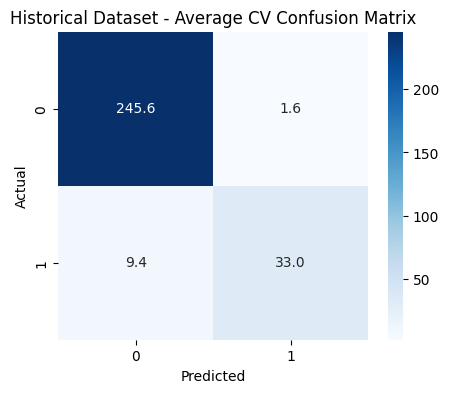

Production Dataset fold=1 | Accuracy=0.983 Precision=1.000 Recall=0.881 Specifity=1.000
Production Dataset fold=2 | Accuracy=0.972 Precision=0.973 Recall=0.837 Specifity=0.996
Production Dataset fold=3 | Accuracy=0.976 Precision=0.974 Recall=0.860 Specifity=0.996
Production Dataset fold=4 | Accuracy=0.969 Precision=0.923 Recall=0.857 Specifity=0.988
Production Dataset fold=5 | Accuracy=0.945 Precision=0.882 Recall=0.714 Specifity=0.984

Production Dataset
Accuracy   : 0.969 ± 0.013
Precision  : 0.950 ± 0.042
Recall     : 0.830 ± 0.060
Specificity: 0.993 ± 0.006


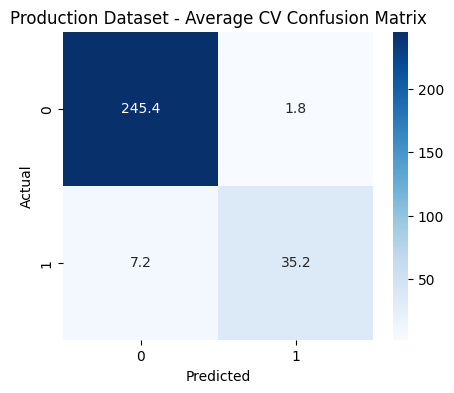

In [228]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Wczytanie danych
# =========================
historical_df = pd.read_csv("data/historical_dataset.csv")
production_df = pd.read_csv("data/production_dataset.csv")

# =========================
# Funkcja do oceny datasetu
# =========================
def evaluate_dataset(df, dataset_name):
    def specificity_score(y_true, y_pred, zero_division=0):
        cm = confusion_matrix(y_true, y_pred)

        if cm.shape != (2, 2):
            return zero_division

        tn, fp, fn, tp = cm.ravel()

        return tn / (tn + fp) if (tn + fp) > 0 else zero_division
    
    X = df.drop(columns=["overpriced"])
    y = df["overpriced"]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    acc_scores = []
    prec_scores = []
    rec_scores = []
    spec_scores = []
    cms = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            # max_depth=6,
            # min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)

        acc_scores.append(accuracy_score(y_val, y_val_pred))
        prec_scores.append(precision_score(y_val, y_val_pred, zero_division=0))
        rec_scores.append(recall_score(y_val, y_val_pred, zero_division=0))
        spec_scores.append(specificity_score(y_val, y_val_pred, zero_division=0))
        cms.append(confusion_matrix(y_val, y_val_pred))

        print(f"{dataset_name} fold={fold} | "
              f"Accuracy={acc_scores[-1]:.3f} "
              f"Precision={prec_scores[-1]:.3f} "
              f"Recall={rec_scores[-1]:.3f} "
              f"Specifity={spec_scores[-1]:.3f}")

    print("\n==============================")
    print(dataset_name)
    print("==============================")
    print(f"Accuracy   : {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
    print(f"Precision  : {np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}")
    print(f"Recall     : {np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}")
    print(f"Specificity: {np.mean(spec_scores):.3f} ± {np.std(spec_scores):.3f}")

    avg_cm = np.mean(cms, axis=0)
    # print("\nAverage confusion matrix:\n", avg_cm)

    # wykres confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(avg_cm, annot=True, fmt=".1f", cmap="Blues")
    plt.title(f"{dataset_name} - Average CV Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return avg_cm

# =========================
# Uruchomienie dla obu datasetów
# =========================
cm_hist = evaluate_dataset(historical_df, "Historical Dataset")
cm_prod = evaluate_dataset(production_df, "Production Dataset")

**Wniosek z transformacji:**
Modele pilotażowe prezentują się bardzo dobrze (wyraźna separacja klas na macierzach pomyłek), co znaczy, że wykreowane cechy nadają się do właściwego modelowania. Choć modele osiągają wymagane analityczne kryterium sukcesu, to mamy nadzieję że proces strojenia hiperparametrów i doboru modelu pozwoli je ulepszyć. Fakt odrzucenia kolumn z danymi historycznymi nie wpływa znacząco na pogorszenie modelu, a nawet może go poprawić.
Zbiór `production_dataset.csv` staje się naszym głównym zbiorem do treningu i selekcji ostatecznego modelu docelowego.
Zbiór `historical.dataset.csv` może się jednak w przyszłości przydać do etykietowania kolejnych ofert.